# Characterization of the Non-Equilibrium Phase Transition of SIS Dynamics on Random Graphs (versió corregida)

Aquest notebook és una segona passada sobre `SIS_lifespan_ADAPTIVE.ipynb`. No repeteix les simulacions de zero:
reaprofita els escanejos ja calculats a `sis_results/adaptive_10K/`, `sis_results/adaptive/` i
`sis_results/adaptive_2/` (són la mateixa xarxa, seed idèntica, només canvia quants runs i quins lambda
s'han escanejat entre les tres))). `adaptive_10K` és la millor font
(50.000 runs/punt en una finestra estreta ben centrada al pic); `adaptive`/`adaptive_2` només tenen 2.000
runs/punt però cobreixen tot el rang de lambda. Combinant-les totes surt un pic net I la corba sencera.

**Altres coses que afegeixo/canvio respecte l'original:**
1. Calculo tau^2 a més de tau. Amb tau només, l'exponent gamma1/nu surt gairebé
   pla o negatiu.  tau^2 dona un pic molt més net.
2. Els plots es queden amb un rang de lambda ample, no només la finestreta estreta al voltant del pic.
   així es veu la corba sencera, no només el cim.




In [1]:
# Imports i configuracio global

import os
import gc
import json
import math
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from scipy.optimize import curve_fit, minimize_scalar
from scipy.interpolate import interp1d

try:
    from numba import njit
    NUMBA_AVAILABLE = True
except Exception:
    NUMBA_AVAILABLE = False
    warnings.warn("Numba is not available. Install numba for the fast Gillespie kernel.")

# Escanejos ja fets (NO els toquem, nomes els llegim).
# adaptive_10K va primer: son 10.000 runs/punt en finestres estretes ben centrades
# al pic (81 punts per gamma,N) -- la millor qualitat que tenim. adaptive/adaptive_2
# nomes tenen 2.000 runs/punt pero cobreixen tot el rang de lambda (bo per veure la
# corba sencera). Es la MATEIXA xarxa a les tres carpetes (mateixa seed, ho he
# comprovat comparant els .npz), aixi que pool_scan_rows les pot combinar totes
# amb les formules exactes sense problema.
# adaptive_boost es la tanda nova que vaig correr al portatil (50.000 runs/punt,
# graella clusteritzada al voltant del pic, les 7 N per als dos gammes ja acabades).
# Te mes pes que tot la resta junta, aixi que nomes afegint-la aqui la mitjana
# ponderada de pool_scan_rows ja la fa dominar el resultat final sense haver de
# tocar res mes de la logica de pooling.
LEGACY_SCAN_DIRS = [
    Path("sis_results/adaptive_10K/adaptive_10K/scans"),
    Path("sis_results/adaptive/adaptive/scans"),
    Path("sis_results/adaptive_2/adaptive_2/scans"),
    Path("sis_results/adaptive_boost/adaptive_10K/scans"),
]

# Aqui es on va tot el que sigui NOU (repeticions extra, xarxes noves, figures finals, taules finals)
RESULTS_DIR = Path("sis_results/final")
GRAPH_DIR = RESULTS_DIR / "graphs"
SCAN_DIR = RESULTS_DIR / "scans"
FIG_DIR = RESULTS_DIR / "figures"

for d in [RESULTS_DIR, GRAPH_DIR, SCAN_DIR, FIG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

BASE_SEED = 12345
REALIZATION_SEED_STEP = 7919  # nombre "gran" qualsevol per separar seeds entre realitzacions

GAMMAS = [3.5, 2.5]
KMIN = 4
REMOVE_PARALLEL = True
CUTOFF = "natural"
N_VALUES = [10_000, 30_000, 50_000, 100_000, 300_000, 500_000, 1_000_000]

# Estil "paper" pels plots (serif, sense spines dalt/dreta).
# Paleta: abans feia servir un colormap sequencial (magma, despres cividis),
# pero amb 7 N's aixo comprimeix les N grans totes cap al mateix extrem fosc
# i es tornen indistingibles. Vaig provar tambe Okabe-Ito (categorica) pero
# amb el groc tan palid i els dos blaus tan semblants quedava lletja. Ara faig
# servir la paleta "vibrant" de Paul Tol (SRON), tambe pensada i validada per
# a daltonisme pero amb mes contrast visual entre colors -- 7 tons ben
# diferenciats, un per cada N, ordenats de calid (N petita) a fred (N gran).
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 9,
    "legend.frameon": False,
    "axes.linewidth": 0.8,
    "lines.linewidth": 1.3,
    "lines.markersize": 4,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linewidth": 0.5,
    "figure.dpi": 130,
    "savefig.dpi": 220,
    "savefig.bbox": "tight",
})

TOL_VIBRANT = [
    "#CC3311",  # vermell   -- N petita
    "#EE7733",  # taronja
    "#EE3377",  # magenta
    "#999933",  # oliva (en comptes del gris de Tol -- es veu millor sobre blanc)
    "#009988",  # verd blavos
    "#33BBEE",  # cian
    "#0077BB",  # blau      -- N gran
]
ACCENT = "#000000"  # negre, reservat nomes per plots sense N (fits, pendents...)

def n_color_map(n_values):
    """Un color de la paleta per cada N, consistent a tots els plots (mateix
    N = mateix color sempre). Paleta categorica (no una gradacio continua) i
    ordenada calid->fred perque, a mes de distingir-se totes entre elles, es
    llegeixi d'un cop d'ull quina es la N petita i quina la gran."""
    n_sorted = sorted(set(n_values))
    return {n: TOL_VIBRANT[i % len(TOL_VIBRANT)] for i, n in enumerate(n_sorted)}

N_COLOR = n_color_map(N_VALUES)

# Paleta alternativa (plasma, sequencial) nomes per a les figures d'estil
# "article" amb llegenda a dalt i panells (a)(b)(c). Evito els extrems (molt
# fosc al principi, molt palid al final) perque totes 7 N es vegin be sobre
# fons blanc, mantenint la separacio de to que fa plasma mes llegible que
# cividis per a les N grans.
def n_color_map_plasma(n_values):
    n_sorted = sorted(set(n_values))
    shades = plt.cm.plasma(np.linspace(0.05, 0.92, len(n_sorted)))
    return {n: shades[i] for i, n in enumerate(n_sorted)}

N_COLOR_PLASMA = n_color_map_plasma(N_VALUES)

def _n_label(N):
    """Etiqueta bonica per a la llegenda ($N=10^4$, $N=3\\times10^4$, ...).
    Fem servir floor (no round) de log10 -- amb round, N=5*10^4 arrodonia
    l'exponent cap amunt (log10(5e4)=4.7 -> 5) i sortia "0x10^5", malament."""
    N = int(N)
    exp = int(math.floor(math.log10(N) + 1e-9))
    mant = N / (10 ** exp)
    if abs(mant - 1.0) < 1e-6:
        return rf"$N=10^{{{exp}}}$"
    return rf"$N={mant:.0f}\times10^{{{exp}}}$"

def clean_ax(ax=None):
    """Treu les spines de dalt i de la dreta -- l'aspecte "paper" que falta ara."""
    ax = ax or plt.gca()
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    return ax

# Estil nomes per a les 3 figures grans de l'informe (2x3 raw+fit, collapse
# abc, peak-height+P_end): lletra mes grossa i sense graella de fons -- amb
# tants panells petits la graella distreu i el text es feia petit de mes.
# S'aplica amb un `with plt.rc_context(REPORT_RC):` nomes al voltant
# d'aquestes figures, no globalment (la resta de plots del notebook es
# queden amb l'estil normal amb graella).
REPORT_RC = {
    "font.size": 15,
    "axes.titlesize": 17,
    "axes.labelsize": 16,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 13,
    "axes.grid": False,
}

print(f"Numba available: {NUMBA_AVAILABLE}")
print(f"Legacy scan dirs: {[str(d) for d in LEGACY_SCAN_DIRS]}")
print(f"New results dir: {RESULTS_DIR.resolve()}")

Numba available: True
Legacy scan dirs: ['sis_results/adaptive_10K/adaptive_10K/scans', 'sis_results/adaptive/adaptive/scans', 'sis_results/adaptive_2/adaptive_2/scans', 'sis_results/adaptive_boost/adaptive_10K/scans']
New results dir: /sessions/vibrant-beautiful-fermi/mnt/ComplexNetworks/sis_lifespan_assignment_package/sis_results/final


## 3. Reaprofitar els escanejos que ja tenim

Els escanejos a `adaptive/` i `adaptive_2/` són (ho he comprovat comparant els fitxers de xarxa `.npz`)
**la mateixa xarxa** per a cada (gamma, N) -- mateixa seed, mateixos edges -- però amb graelles de lambda
diferents. Per tant no els puc "promitjar" com si fossin dues realitzacions independents: el que tinc són
més punts de lambda sobre la mateixa corba. Els ajunto i, si per casualitat coincideix algun lambda exacte
entre els dos fitxers (o més endavant afegeixo repeticions al mateix punt), els combino amb les fórmules
exactes de mitjana/variància ponderada -- no fent la mitjana de mitjanes, que dona un resultat lleugerament
esbiaixat si el nombre de runs no és el mateix a cada bloc.

Com que els escanejos vells no tenen la columna `tau2_mean` (l'he afegit ara), la reconstrueixo de forma
exacta a partir de `tau_mean` i `tau_std`: si `var = tau_std**2` amb ddof=1, llavors
`E[tau^2] = var*(n-1)/n + mean**2` és exacte donat que sabem `n` (no és una aproximació).


In [4]:
# Reconstruccio de tau2 per als escanejos vells + pooling exacte

def reconstruct_tau2_if_missing(df):
    """Si una fila es d'un CSV vell i no te tau2_mean, la recuperem de forma
    exacta a partir de tau_mean i tau_std (ddof=1) i n_nonendemic.

    OJO: aixo s'ha de fer FILA A FILA, no columna a columna. Si nomes mirem
    "la columna tau2_mean ja existeix?" per tota la taula, en el moment que
    ajuntem escanejos vells (sense tau2_mean) amb escanejos nous (que ja la
    porten calculada) la columna "existeix" pero nomes per algunes files --
    i totes les files velles es quedarien amb NaN. Aquest era el bug que feia
    que el plot de tau^2 sortis buit i que la seccio 9 acabes petant.
    """
    df = df.copy()
    if "tau2_mean" not in df.columns:
        df["tau2_mean"] = np.nan

    n = df["n_nonendemic"].astype(float)
    mean = df["tau_mean"].astype(float)
    std = df["tau_std"].astype(float)

    # amb n<=1 no tenim std (surt NaN a l'origen), llavors tau2 = mean^2 (un sol punt, sense variancia)
    var_term = np.where(n > 1, (std ** 2) * (n - 1) / n, 0.0)
    reconstructed = var_term + mean ** 2
    reconstructed = np.where(n > 0, reconstructed, np.nan)

    missing = df["tau2_mean"].isna().values
    df.loc[missing, "tau2_mean"] = reconstructed[missing]
    return df

def pool_scan_rows(df, lambda_decimals=6):
    """
    Combina files que corresponen al mateix (gamma, N, lambda) -- ja siguin
    repeticions extra, realitzacions de xarxa diferents, o coincidencies de
    graella -- fent servir les formules exactes de mitjana/variancia ponderada
    (l'algorisme "parallel" de combinacio de moments), no la mitjana de mitjanes.
    """
    df = df.copy()
    df["lambda_r"] = df["lambda"].round(lambda_decimals)

    rows = []
    for (gamma, N, lam), g in df.groupby(["gamma", "N", "lambda_r"]):
        n_runs = int(g["n_runs"].sum())
        n_end = int(g["n_endemic"].sum())
        n_non = int(g["n_nonendemic"].sum())

        P_end = n_end / n_runs if n_runs > 0 else np.nan
        P_end_se = math.sqrt(P_end * (1 - P_end) / n_runs) if n_runs > 0 else np.nan

        valid = g[(g["n_nonendemic"] > 0) & np.isfinite(g["tau_mean"])]

        if len(valid) == 0 or n_non == 0:
            tau_mean = np.nan
            tau_std = np.nan
            tau_se = np.nan
            tau2_mean = np.nan
        else:
            w = valid["n_nonendemic"].values.astype(float)
            m = valid["tau_mean"].values.astype(float)
            tau_mean = float(np.sum(w * m) / np.sum(w))

            # variancia combinada (nomes amb els blocs que en tenen, n>1)
            var_rows = valid[(valid["n_nonendemic"] > 1) & np.isfinite(valid["tau_std"])]
            if len(var_rows) > 0:
                wv = var_rows["n_nonendemic"].values.astype(float)
                mv = var_rows["tau_mean"].values.astype(float)
                sv = var_rows["tau_std"].values.astype(float)
                M2 = np.sum((wv - 1) * sv ** 2 + wv * (mv - tau_mean) ** 2)
                n_var = wv.sum()
                tau_std = float(np.sqrt(M2 / (n_var - 1))) if n_var > 1 else np.nan
            else:
                tau_std = np.nan
            tau_se = tau_std / math.sqrt(n_non) if (np.isfinite(tau_std) and n_non > 0) else np.nan

            t2 = valid["tau2_mean"].values.astype(float)
            tau2_mean = float(np.sum(w * t2) / np.sum(w))

        rows.append({
            "gamma": gamma, "N": int(N), "lambda": lam,
            "n_runs": n_runs, "n_endemic": n_end, "n_nonendemic": n_non,
            "P_end": P_end, "P_end_se": P_end_se,
            "tau_mean": tau_mean, "tau_std": tau_std, "tau_se": tau_se, "tau2_mean": tau2_mean,
        })

    return pd.DataFrame(rows).sort_values(["gamma", "N", "lambda"]).reset_index(drop=True)

## 4. Carreguem tot el que ja tenim calculat

Llegim tots els `scan_gamma*_N*.csv` de les carpetes legacy (`adaptive`, `adaptive_2`) més qualsevol cosa
nova que hàgim generat a `SCAN_DIR` (secció següent), i ho ajuntem amb `pool_scan_rows`.


In [5]:
# Carrega tots els escanejos disponibles (legacy + nous) i els combina

def _source_tag(path_str):
    """A quina carpeta pertany cada fitxer. Ho faig servir mes endavant per NO barrejar
    fonts de resolucio molt diferent dins d'una mateixa linia d'un plot (adaptive_10K son
    10.000 runs/punt en una finestra molt estreta al voltant del pic; adaptive/adaptive_2
    nomes 2.000 runs/punt pero amb tot el rang de lambda). Per als fits numerics si que
    les ajuntem totes (pool_scan_rows), aqui nomes serveix per triar que es dibuixa junt.

    OJO amb l'ordre: adaptive_boost/adaptive_10K/scans conte el substring "adaptive_10K"
    dins del path, aixi que el check de adaptive_boost ha d'anar SEMPRE abans, si no
    tota la tanda nova (50.000 runs/punt, la que fem servir per la finestra del pic)
    es confonia amb la carpeta legacy adaptive_10K (10.000 runs/punt)."""
    if "adaptive_boost" in path_str:
        return "adaptive_boost"
    if "adaptive_10K" in path_str:
        return "adaptive_10K"
    if "adaptive_2" in path_str:
        return "adaptive_2"
    if "adaptive" in path_str:
        return "adaptive"
    return "final"

def load_all_raw_scans():
    files = []
    for d in LEGACY_SCAN_DIRS:
        if d.exists():
            files += sorted(d.glob("scan_gamma*_N*.csv"))
        else:
            print(f"[avis] no trobo la carpeta legacy {d} (revisa el path si cal)")
    if SCAN_DIR.exists():
        files += sorted(SCAN_DIR.glob("scan_gamma*_N*.csv"))

    if not files:
        return pd.DataFrame()

    dfs = []
    for f in files:
        d = pd.read_csv(f)
        d["source_file"] = str(f)
        dfs.append(d)
    raw = pd.concat(dfs, ignore_index=True)
    raw["source_tag"] = raw["source_file"].apply(_source_tag)
    # reconstruim tau2_mean aqui mateix (no nomes a dins de load_and_pool_all) perque
    # raw_scans tambe el faig servir tal qual a la seccio 9b (col·lapse nomes amb
    # adaptive_10K) -- si no ho fes aqui, les files d'adaptive_10K es quedarien amb
    # tau2_mean a NaN (cap CSV vell el porta de fabrica) i el col·lapse de tau^2
    # sortiria buit/degenerat encara que results (la taula agregada) si que l'ompli be.
    raw = reconstruct_tau2_if_missing(raw)
    return raw

def load_and_pool_all(raw):
    if raw.empty:
        print("Cap escaneig trobat -- results quedara buit.")
        return pd.DataFrame()
    return pool_scan_rows(raw)

raw_scans = load_all_raw_scans()
results = load_and_pool_all(raw_scans)
print("results shape:", results.shape)
if not results.empty:
    print(results.groupby("gamma")["N"].apply(lambda s: sorted(s.unique())))

results shape: (2907, 12)
gamma
2.5    [10000, 30000, 50000, 100000, 300000, 500000, ...
3.5    [10000, 30000, 50000, 100000, 300000, 500000, ...
Name: N, dtype: object


## 6. Inspeccionem `results`

A partir d'aquí tot el que segueix fa servir el dataframe `results` (gamma, N, lambda, P_end, tau_mean,
tau2_mean...), independentment de si ve només de les dades legacy o si li hem afegit repeticions/realitzacions
noves a la secció anterior.


In [8]:
print("results:", results.shape)
display(results.sort_values(["gamma", "N", "lambda"]).head())

for gamma in sorted(results["gamma"].unique()):
    sub = results[results["gamma"] == gamma]
    print(f"gamma={gamma}: N values = {sorted(sub['N'].unique())}, "
          f"punts de lambda totals = {len(sub)}")

results: (2907, 12)


,gamma,N,lambda,n_runs,n_endemic,n_nonendemic,P_end,P_end_se,tau_mean,tau_std,tau_se,tau2_mean
0,2.5,10000,0.001,2000,0,2000,0.0,0.0,0.995032,0.972859,0.021754,1.936071
1,2.5,10000,0.002,2000,0,2000,0.0,0.0,0.999371,0.999862,0.022358,1.997967
2,2.5,10000,0.003,2000,0,2000,0.0,0.0,1.026816,1.036127,0.023168,2.127373
3,2.5,10000,0.004,2000,0,2000,0.0,0.0,1.004309,1.028873,0.023006,2.066686
4,2.5,10000,0.005,52000,0,52000,0.0,0.0,1.010891,1.013163,0.004443,2.048379


gamma=2.5: N values = [np.int64(10000), np.int64(30000), np.int64(50000), np.int64(100000), np.int64(300000), np.int64(500000), np.int64(1000000)], punts de lambda totals = 1377
gamma=3.5: N values = [np.int64(10000), np.int64(30000), np.int64(50000), np.int64(100000), np.int64(300000), np.int64(500000), np.int64(1000000)], punts de lambda totals = 1530


## 7. Corbes tau(lambda,N), tau^2(lambda,N) i P_end(lambda,N)

Faig servir tau **i** tau^2 (amb tau^2 el pic queda molt més marcat, perquè pesa més les cues llargues
del lifespan a prop del punt crític).

Aquests no son els definitius.


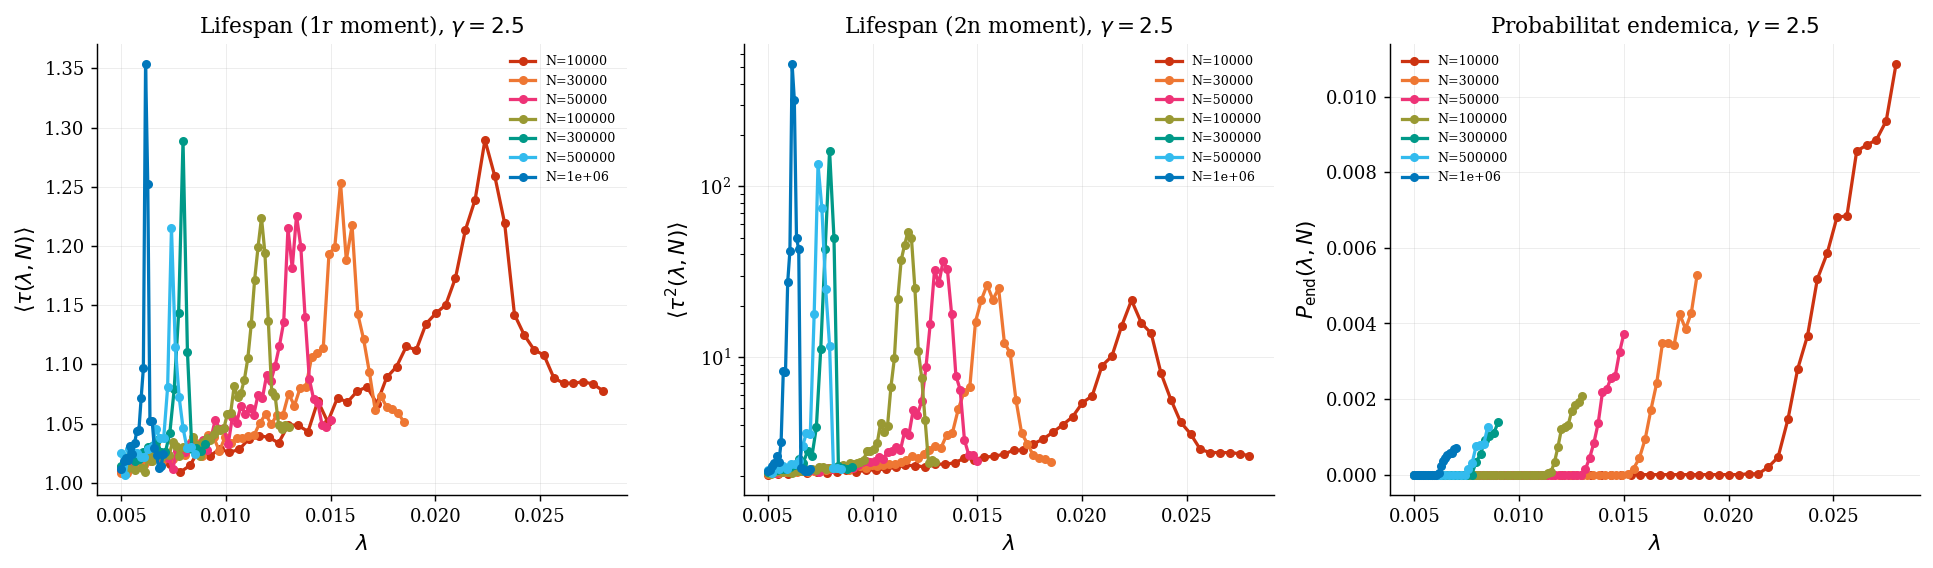

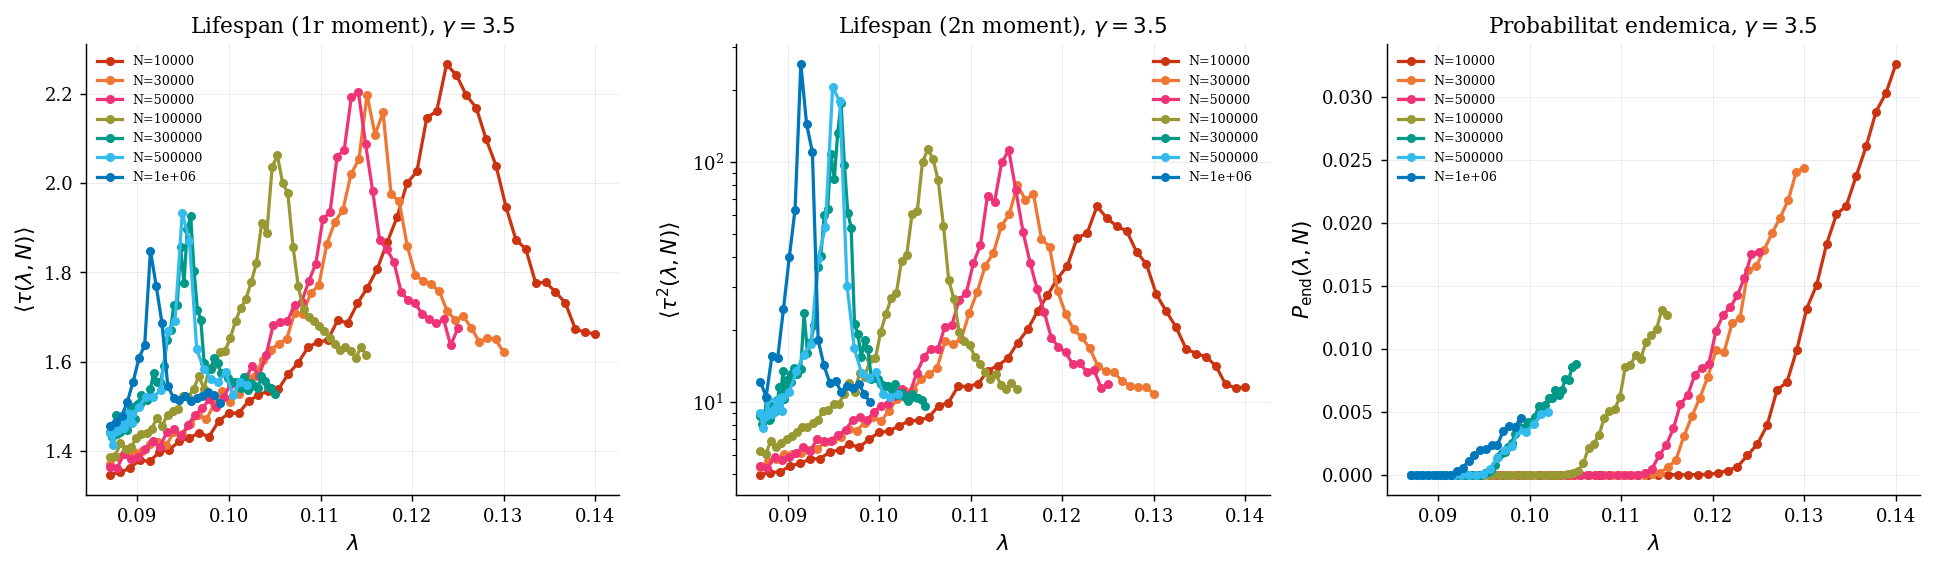

In [9]:
# Plot de tau, tau^2 i P_end en funcio de lambda, per a cada N
# NOTA: aixo NOMES afecta com es dibuixa. Els fits de veritat (seccions 8-11) fan
# servir `results`, que ja te totes les fonts ajuntades amb pool_scan_rows.
# Nomes pinto adaptive_boost (50.000 runs/punt, graella clusteritzada al pic).
# Abans hi afegia per sota les tandes velles (adaptive/adaptive_2/adaptive_10K,
# rang ample pero nomes 2.000-10.000 runs/punt) com a linies fines de "context"
# per veure la forma sencera de la corba -- pero com que cobreixen un rang de
# lambda molt mes ample que la finestra del pic, feien que l'eix x s'estirés i
# el plot es vegi desproporcionat i carregat. Amb nomes adaptive_boost l'eix ja
# s'ajusta sol a la zona rellevant.
PEAK_TAGS = ("adaptive_boost",)

def pool_same_tag(sub_raw, tags):
    """Nomes ajunta files que venen del mateix grup de fonts (mateixa resolucio de
    lambda i mateix nombre de runs/punt aprox). Fer-ho aixi -- en comptes de barrejar
    totes les fonts en una sola linia -- es el que evita que la corba surti dentada."""
    part = sub_raw[sub_raw["source_tag"].isin(tags)]
    if part.empty:
        return pd.DataFrame()
    return pool_scan_rows(part)

def plot_tau_tau2_and_pend(raw, gamma):
    sub_raw = raw[raw["gamma"] == gamma]
    if sub_raw.empty:
        print(f"No hi ha resultats per gamma={gamma}")
        return

    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

    for N in sorted(sub_raw["N"].unique()):
        color = N_COLOR.get(int(N), ACCENT)
        sub_N = sub_raw[sub_raw["N"] == N]

        g_pk = pool_same_tag(sub_N, PEAK_TAGS)
        if g_pk.empty:
            continue
        g_pk = g_pk.sort_values("lambda")

        axes[0].plot(g_pk["lambda"], g_pk["tau_mean"], "o-", ms=4, lw=1.8, color=color, label=f"N={N:g}")
        axes[1].plot(g_pk["lambda"], g_pk["tau2_mean"], "o-", ms=4, lw=1.8, color=color, label=f"N={N:g}")
        axes[2].plot(g_pk["lambda"], g_pk["P_end"], "o-", ms=4, lw=1.8, color=color, label=f"N={N:g}")

    axes[0].set_xlabel(r"$\lambda$"); axes[0].set_ylabel(r"$\langle \tau(\lambda,N)\rangle$")
    axes[0].set_title(rf"Lifespan (1r moment), $\gamma={gamma}$")

    axes[1].set_xlabel(r"$\lambda$"); axes[1].set_ylabel(r"$\langle \tau^2(\lambda,N)\rangle$")
    axes[1].set_title(rf"Lifespan (2n moment), $\gamma={gamma}$")
    axes[1].set_yscale("log")

    axes[2].set_xlabel(r"$\lambda$"); axes[2].set_ylabel(r"$P_{\rm end}(\lambda,N)$")
    axes[2].set_title(rf"Probabilitat endemica, $\gamma={gamma}$")

    for ax in axes:
        clean_ax(ax)
        ax.legend(fontsize=7)

    plt.tight_layout()
    plt.savefig(FIG_DIR / f"tau_tau2_pend_gamma{gamma}.png")
    plt.show()

for gamma in sorted(raw_scans["gamma"].unique()) if not raw_scans.empty else []:
    plot_tau_tau2_and_pend(raw_scans, gamma)

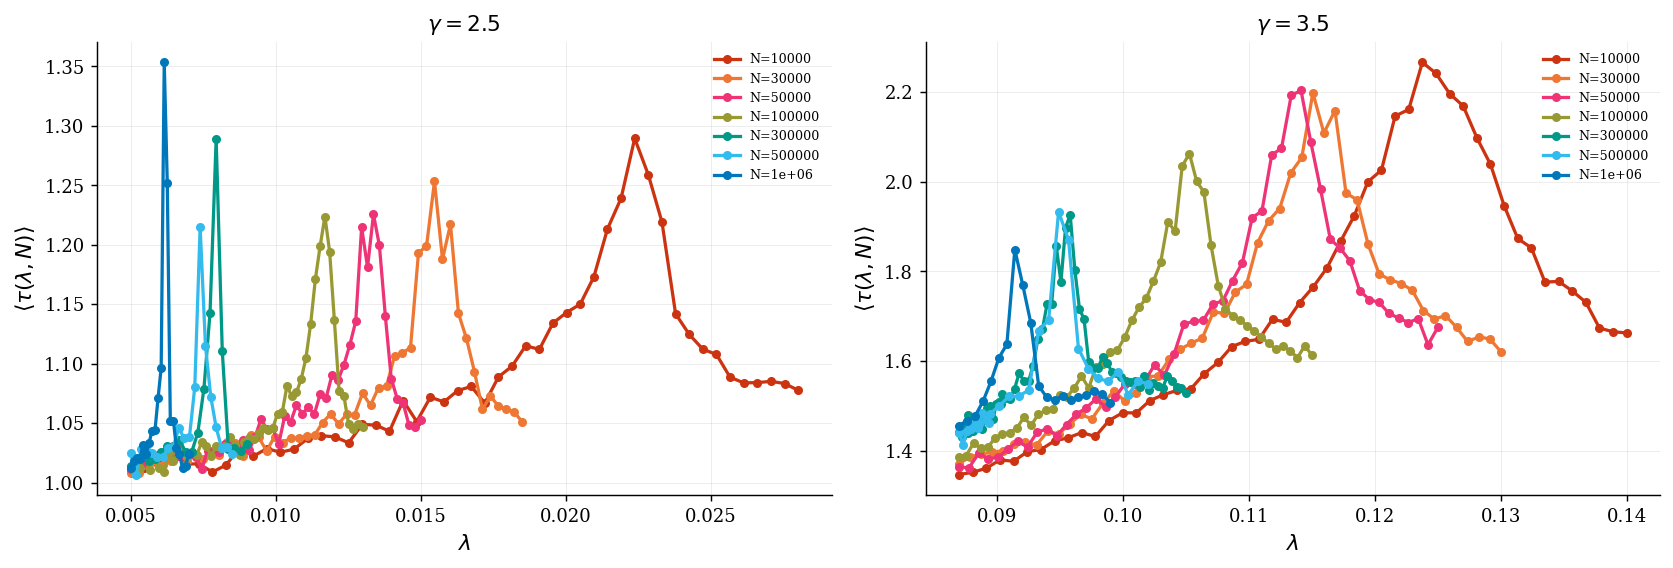

In [10]:
# Figura compacta per a l'informe: <tau(lambda,N)> vs lambda, els dos gammes
# junts en un sol plot de 2 panells (demanat explicitament pel punt 3 de
# l'enunciat, abans nomes en teniem la versio de 3 panells per gamma de dalt)

gammas_ok = sorted(raw_scans["gamma"].unique()) if not raw_scans.empty else []
if gammas_ok:
    fig, axes = plt.subplots(1, len(gammas_ok), figsize=(6.5 * len(gammas_ok), 4.5), squeeze=False)
    axes = axes[0]
    for ax, gamma in zip(axes, gammas_ok):
        sub_raw = raw_scans[raw_scans["gamma"] == gamma]
        for N in sorted(sub_raw["N"].unique()):
            color = N_COLOR.get(int(N), ACCENT)
            g_pk = pool_same_tag(sub_raw[sub_raw["N"] == N], PEAK_TAGS)
            if g_pk.empty:
                continue
            g_pk = g_pk.sort_values("lambda")
            ax.plot(g_pk["lambda"], g_pk["tau_mean"], "o-", ms=4, lw=1.8, color=color, label=f"N={N:g}")
        ax.set_xlabel(r"$\lambda$"); ax.set_ylabel(r"$\langle\tau(\lambda,N)\rangle$")
        ax.set_title(rf"$\gamma={gamma}$")
        clean_ax(ax)
        ax.legend(fontsize=7)
    plt.tight_layout()
    plt.savefig(FIG_DIR / "raw_tau_combined.png")
    plt.show()

## 8. Posició del pic i estimació de lambda_c i 1/nu

Fem servir el pic de `tau` (1r moment) per trobar lambda_p(N), com fa l'enunciat (Eq. 2/4 del PDF, que
parlen de `<tau>`). Després ajustem

lambda_p(N) = lambda_c + a·N^(-1/nu)



gamma=2.5: fit lliure -> lambda_c=0.00263, 1/nu=0.369, cost=5.202e-07
  robustesa (fixant 1/nu a una graella de valors de referencia):
 gamma  inv_nu_fixed  lambda_c_fixed  a_fixed         cost
   2.5         0.100       -0.021936 0.107704 6.509197e-06
   2.5         0.150       -0.010697 0.127216 4.482497e-06
   2.5         0.200       -0.005079 0.168093 2.865759e-06
   2.5         0.250       -0.001709 0.235586 1.670943e-06
   2.5         0.300        0.000537 0.342039 9.005706e-07
   2.5         0.353        0.002225 0.520513 5.395671e-07
gamma=3.5: fit lliure -> lambda_c=3.571e-07, 1/nu=0.0681, cost=1.492e-05
  robustesa (fixant 1/nu a una graella de valors de referencia):
 gamma  inv_nu_fixed  lambda_c_fixed  a_fixed     cost
   3.5         0.100        0.033846 0.228252 0.000016
   3.5         0.150        0.058010 0.267678 0.000019
   3.5         0.200        0.070094 0.351103 0.000024
   3.5         0.250        0.077348 0.488414 0.000032
   3.5         0.300        0.082188 0.

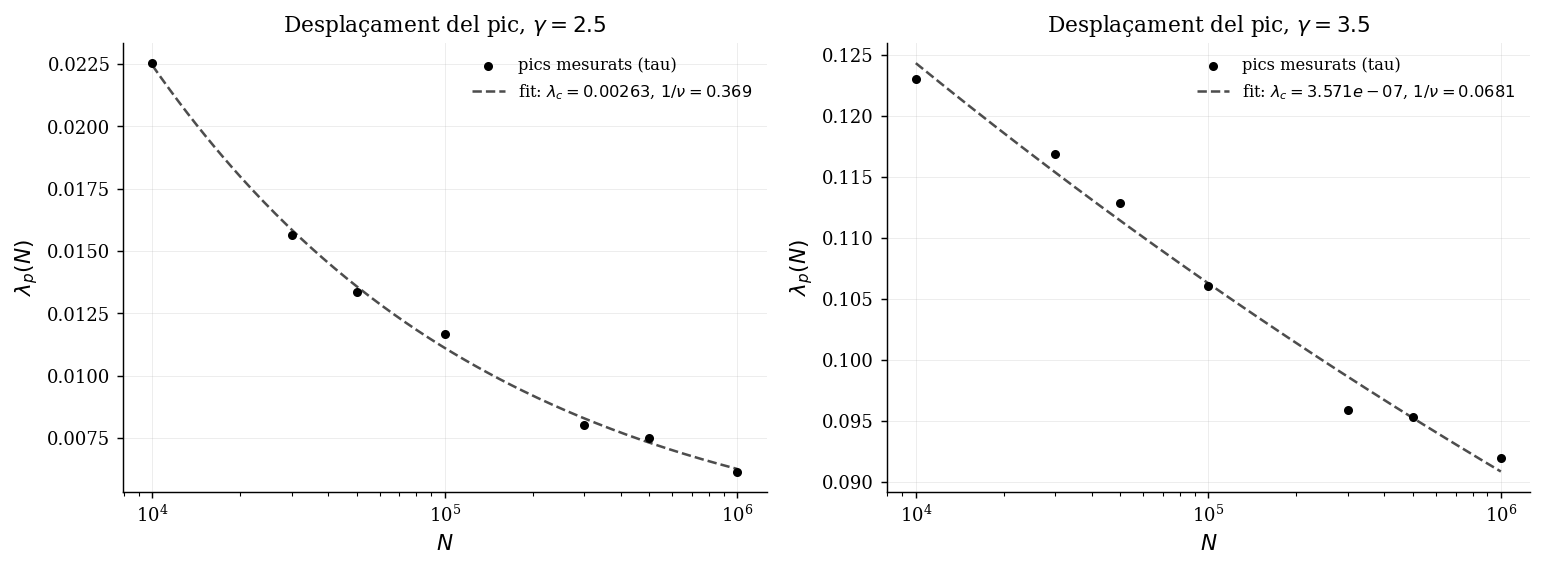

,gamma,N,lambda_p,peak
0,2.5,10000,0.022540,1.398703
1,2.5,30000,0.015641,1.921238
2,2.5,50000,0.013356,1.406702
3,2.5,100000,0.011667,1.453653
4,2.5,300000,0.008023,1.397519
5,2.5,500000,0.007487,1.383128
6,2.5,1000000,0.006158,1.353498
7,3.5,10000,0.123078,2.289534
8,3.5,30000,0.116904,2.297125
9,3.5,50000,0.112879,2.237860


,gamma,lambda_c,lambda_c_err,a,a_err,inv_nu,inv_nu_err,fit_cost
0,2.5,2.630226e-03,0.001034,0.591249,0.194836,0.368639,0.040110,5.201572e-07
1,3.5,3.571270e-07,0.154306,0.232900,0.076162,0.068132,0.098823,1.491873e-05


,gamma,inv_nu_fixed,lambda_c_fixed,a_fixed,cost
0,2.5,0.100,-0.021936,0.107704,6.509197e-06
1,2.5,0.150,-0.010697,0.127216,4.482497e-06
2,2.5,0.200,-0.005079,0.168093,2.865759e-06
3,2.5,0.250,-0.001709,0.235586,1.670943e-06
4,2.5,0.300,0.000537,0.342039,9.005706e-07
5,2.5,0.353,0.002225,0.520513,5.395671e-07
6,3.5,0.100,0.033846,0.228252,1.579421e-05
7,3.5,0.150,0.058010,0.267678,1.896274e-05
8,3.5,0.200,0.070094,0.351103,2.428875e-05
9,3.5,0.250,0.077348,0.488414,3.168990e-05


In [11]:
# Estimacio de la posicio del pic i fit de lambda_c, 1/nu

def peak_estimate(x, y, window=3):
    """
    Parabola local al voltant del maxim. window=3 es el comportament original
    (nomes el punt i els dos veins); per a corbes mes sorolloses (tau^2 a prop
    del pic) es pot fer servir una finestra mes ampla per suavitzar una mica.
    """
    x = np.asarray(x, dtype=float); y = np.asarray(y, dtype=float)
    mask = np.isfinite(x) & np.isfinite(y)
    x, y = x[mask], y[mask]
    if len(x) == 0:
        # cap punt finit (per exemple una N amb molt poques repeticions noves
        # i cap dada legacy per aquell ycol) -- no petem, retornem NaN i que
        # el que ho faci servir ho gestioni.
        return np.nan, np.nan
    if len(x) < 3:
        idx = np.nanargmax(y)
        return float(x[idx]), float(y[idx])

    order = np.argsort(x); x, y = x[order], y[order]
    idx = int(np.nanargmax(y))
    half = window // 2
    lo, hi = max(0, idx - half), min(len(x), idx + half + 1)
    if hi - lo < 3:
        return float(x[idx]), float(y[idx])

    xs, ys = x[lo:hi], y[lo:hi]
    try:
        aa, bb, cc = np.polyfit(xs, ys, 2)
        if aa < 0:
            xp = -bb / (2 * aa)
            yp = aa * xp * xp + bb * xp + cc
            if xs[0] <= xp <= xs[-1]:
                return float(xp), float(yp)
    except Exception:
        pass
    return float(x[idx]), float(y[idx])

def extract_peaks(results, gamma, ycol, window=3):
    rows = []
    sub = results[results["gamma"] == gamma]
    for N, g in sub.groupby("N"):
        g = g.sort_values("lambda")
        xp, yp = peak_estimate(g["lambda"].values, g[ycol].values, window=window)
        rows.append({"gamma": gamma, "N": int(N), "lambda_p": xp, "peak": yp})
    return pd.DataFrame(rows).sort_values("N")

def lambda_peak_model(N, lambda_c, a, inv_nu):
    return lambda_c + a * N ** (-inv_nu)

def robust_fit_lambda_c(peaks, invnu_starts=(0.1, 0.2, 0.3, 0.5, 0.7, 1.0)):
    """
    Prova diversos punts de partida per a 1/nu i es queda amb el fit de menor
    residu. Tambe imposa lambda_c < min(lambda_p) -- fisicament el pic finit
    sempre esta per sobre del punt critic asimptotic.
    """
    N = peaks["N"].values.astype(float)
    lp = peaks["lambda_p"].values.astype(float)
    lp_min = lp.min()

    best = None
    for invnu0 in invnu_starts:
        p0 = [lp_min * 0.5, (lp.max() - lp.min()) if lp.max() > lp.min() else 0.01, invnu0]
        bounds = ([0.0, 1e-8, 0.02], [lp_min * 0.999, np.inf, 2.0])
        try:
            popt, pcov = curve_fit(lambda_peak_model, N, lp, p0=p0, bounds=bounds, maxfev=200_000)
            resid = lp - lambda_peak_model(N, *popt)
            cost = float(np.sum(resid ** 2))
            if best is None or cost < best[0]:
                perr = np.sqrt(np.diag(pcov))
                best = (cost, popt, perr)
        except Exception:
            continue
    return best

def fixed_invnu_scan(peaks, invnu_grid=(0.10, 0.15, 0.20, 0.25, 0.30, 0.353)):
    """
    Fixo 1/nu a una graella de valors "raonables" (des de gairebe pla fins al
    valor que surt del fit lliure) i reajusto nomes lambda_c i a (lineal, sense
    necessitat de curve_fit). Aixo demostra si el fit lliure esta realment
    degenerat: si el cost gairebe no varia al llarg d'aquest rang, vol dir que
    les dades NO distingeixen entre "lambda_c~0, 1/nu petit" i "lambda_c mes
    gran, 1/nu mes gran" -- no es que estigui triant malament, es que la corba
    de 7 punts en 2 dècades de N es compatible amb tots dos alhora.
    """
    N = peaks["N"].values.astype(float)
    lp = peaks["lambda_p"].values.astype(float)
    rows = []
    for invnu in invnu_grid:
        x = N ** (-invnu)
        A = np.vstack([np.ones_like(x), x]).T
        coef, *_ = np.linalg.lstsq(A, lp, rcond=None)
        lc, a = coef
        cost = float(np.sum((lp - (lc + a * x)) ** 2))
        rows.append({"inv_nu_fixed": invnu, "lambda_c_fixed": lc, "a_fixed": a, "cost": cost})
    return pd.DataFrame(rows)

all_peak_rows = []
fit_summary = []
robustness_rows = []
fit_results = {}  # gamma -> (peaks, popt) -- ho guardo per fer despres un sol plot amb tots dos gammes

for gamma in sorted(results["gamma"].unique()) if not results.empty else []:
    peaks = extract_peaks(results, gamma, "tau_mean", window=3)
    peaks = peaks.dropna(subset=["lambda_p", "peak"])
    all_peak_rows.append(peaks)

    if len(peaks) < 3:
        print(f"gamma={gamma}: nomes {len(peaks)} mides amb pic valid -- no es pot fer el fit (calen >=3).")
        continue

    fit = robust_fit_lambda_c(peaks)
    if fit is None:
        print(f"gamma={gamma}: cap fit ha convergit, revisa les dades.")
        continue

    cost, popt, perr = fit
    lambda_c, a, inv_nu = popt
    lambda_c_err, a_err, inv_nu_err = perr
    fit_summary.append({
        "gamma": gamma, "lambda_c": lambda_c, "lambda_c_err": lambda_c_err,
        "a": a, "a_err": a_err, "inv_nu": inv_nu, "inv_nu_err": inv_nu_err,
        "fit_cost": cost,
    })
    fit_results[gamma] = (peaks, popt)

    # comprovacio de degeneracio: quant costa fixar 1/nu a altres valors "raonables"?
    rdf = fixed_invnu_scan(peaks)
    rdf.insert(0, "gamma", gamma)
    robustness_rows.append(rdf)
    print(f"gamma={gamma}: fit lliure -> lambda_c={lambda_c:.4g}, 1/nu={inv_nu:.3g}, cost={cost:.3e}")
    print("  robustesa (fixant 1/nu a una graella de valors de referencia):")
    print(rdf.to_string(index=False))
    if (rdf["cost"] <= 3 * cost).all():
        print("  [avis] el cost gairebe no varia en tot aquest rang de 1/nu -- el fit lliure "
              "esta degenerat, lambda_c~0 NO es un resultat mes fiable que lambda_c mes gran "
              "amb un 1/nu tambe mes gran (vegeu seccio de discussio).")

# Un sol plot amb els dos gammes costat a costat (abans en sortien dos de separats)
gammas_ok = sorted(fit_results.keys())
if gammas_ok:
    fig, axes = plt.subplots(1, len(gammas_ok), figsize=(6 * len(gammas_ok), 4.5), squeeze=False)
    axes = axes[0]
    for ax, gamma in zip(axes, gammas_ok):
        peaks, popt = fit_results[gamma]
        lambda_c, a, inv_nu = popt
        N_plot = np.logspace(np.log10(peaks["N"].min()), np.log10(peaks["N"].max()), 200)
        ax.scatter(peaks["N"], peaks["lambda_p"], color=ACCENT, zorder=3, label="pics mesurats (tau)")
        ax.plot(N_plot, lambda_peak_model(N_plot, *popt), color="0.3", lw=1.4, ls="--",
                label=rf"fit: $\lambda_c={lambda_c:.4g}$, $1/\nu={inv_nu:.3g}$")
        ax.set_xscale("log")
        ax.set_xlabel(r"$N$"); ax.set_ylabel(r"$\lambda_p(N)$")
        ax.set_title(rf"Desplaçament del pic, $\gamma={gamma}$")
        clean_ax(ax)
        ax.legend()
    plt.tight_layout()
    plt.savefig(FIG_DIR / "lambda_peak_fit_combined.png")
    plt.show()

peaks_df = pd.concat(all_peak_rows, ignore_index=True) if all_peak_rows else pd.DataFrame()
fit_df = pd.DataFrame(fit_summary)
robustness_df = pd.concat(robustness_rows, ignore_index=True) if robustness_rows else pd.DataFrame()

display(peaks_df)
display(fit_df)
if not robustness_df.empty:
    display(robustness_df)
    robustness_df.to_csv(RESULTS_DIR / "lambda_c_robustness_fixed_invnu.csv", index=False)

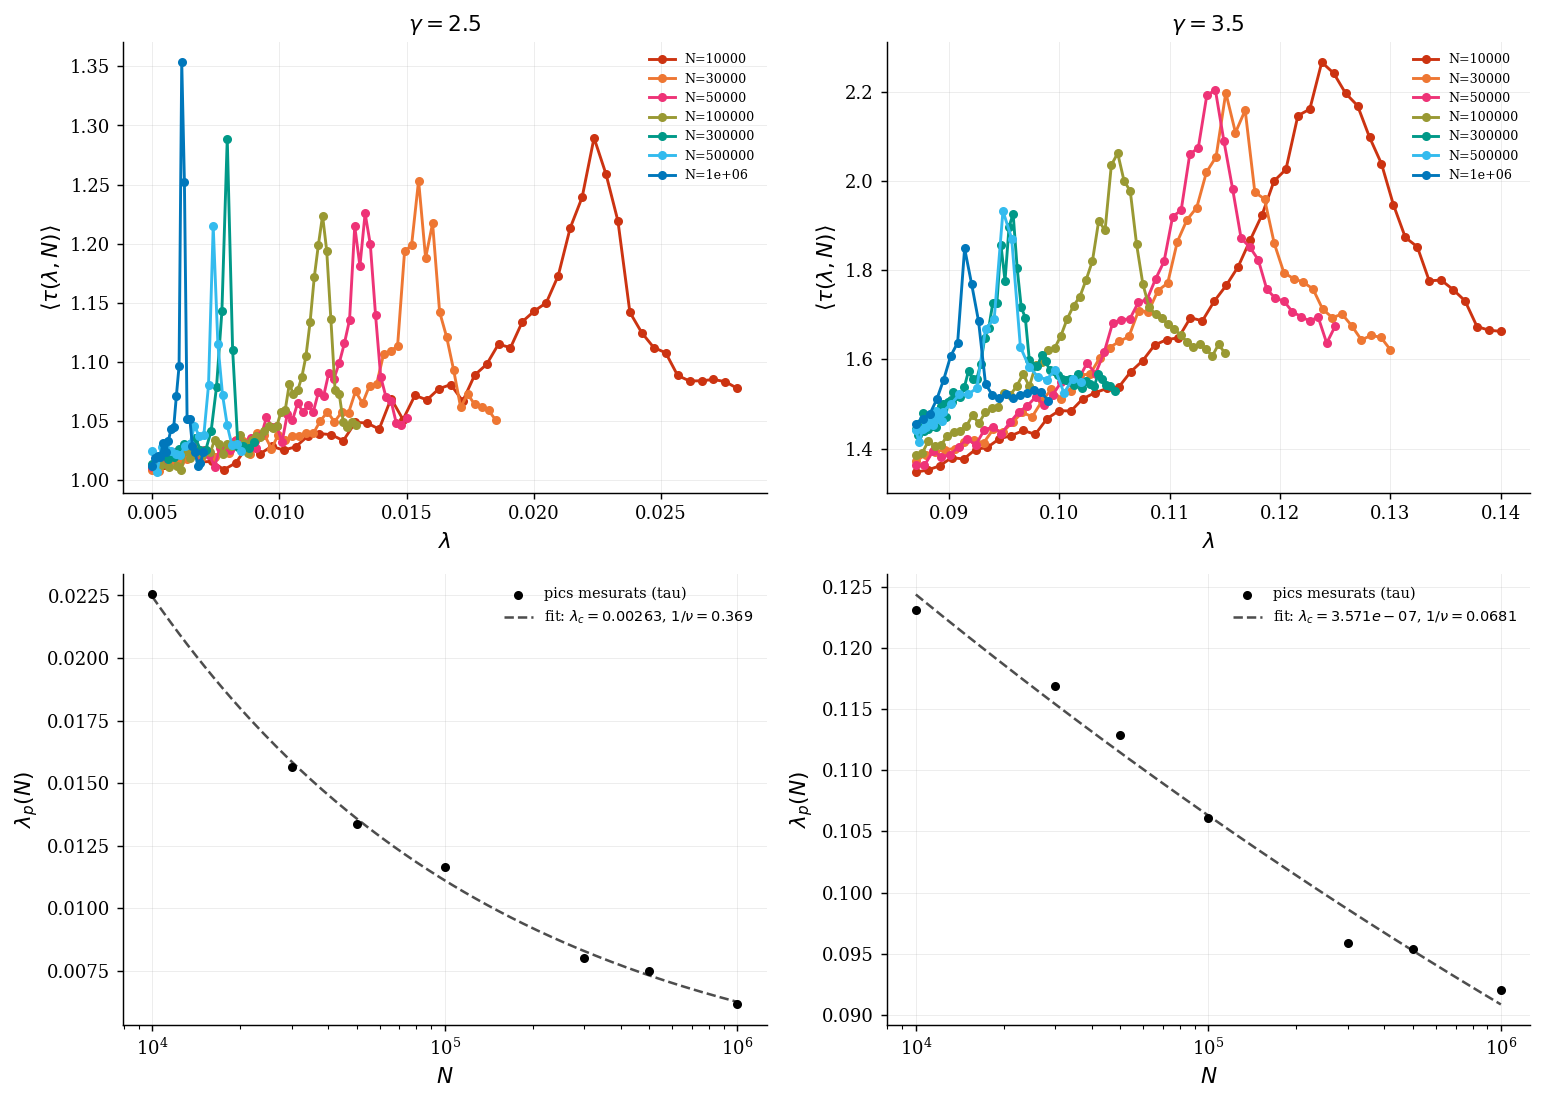

In [12]:
# Figura nativa per a l'informe (punt 3 de l'enunciat): graella 2x2 vectorial
# (PDF), fila de dalt = corbes de tau(lambda,N), fila de baix = fit del
# desplacament del pic. Abans muntava aixo ajuntant dues imatges PNG amb PIL,
# pero surt millor generar-ho directament com una sola figura de matplotlib
# (vectorial, es veu be a qualsevol zoom dins el PDF de l'informe).

gammas_ok_p3 = sorted(fit_results.keys())
if gammas_ok_p3:
    fig, axes = plt.subplots(2, len(gammas_ok_p3), figsize=(6 * len(gammas_ok_p3), 8.6), squeeze=False)

    for col, gamma in enumerate(gammas_ok_p3):
        sub_raw = raw_scans[raw_scans["gamma"] == gamma]
        ax_tau = axes[0][col]
        for N in sorted(sub_raw["N"].unique()):
            color = N_COLOR.get(int(N), ACCENT)
            g_pk = pool_same_tag(sub_raw[sub_raw["N"] == N], PEAK_TAGS)
            if g_pk.empty:
                continue
            g_pk = g_pk.sort_values("lambda")
            ax_tau.plot(g_pk["lambda"], g_pk["tau_mean"], "o-", ms=4, lw=1.6, color=color, label=f"N={N:g}")
        ax_tau.set_xlabel(r"$\lambda$"); ax_tau.set_ylabel(r"$\langle\tau(\lambda,N)\rangle$")
        ax_tau.set_title(rf"$\gamma={gamma}$")
        clean_ax(ax_tau)
        ax_tau.legend(fontsize=7)

        peaks, popt = fit_results[gamma]
        lambda_c, a, inv_nu = popt
        N_plot = np.logspace(np.log10(peaks["N"].min()), np.log10(peaks["N"].max()), 200)
        ax_fit = axes[1][col]
        ax_fit.scatter(peaks["N"], peaks["lambda_p"], color=ACCENT, zorder=3, label="pics mesurats (tau)")
        ax_fit.plot(N_plot, lambda_peak_model(N_plot, *popt), color="0.3", lw=1.4, ls="--",
                    label=rf"fit: $\lambda_c={lambda_c:.4g}$, $1/\nu={inv_nu:.3g}$")
        ax_fit.set_xscale("log")
        ax_fit.set_xlabel(r"$N$"); ax_fit.set_ylabel(r"$\lambda_p(N)$")
        clean_ax(ax_fit)
        ax_fit.legend(fontsize=8)

    plt.tight_layout()
    plt.savefig(FIG_DIR / "report_point3.png")
    plt.savefig(FIG_DIR / "report_point3.pdf")
    plt.show()

# El plot per al report

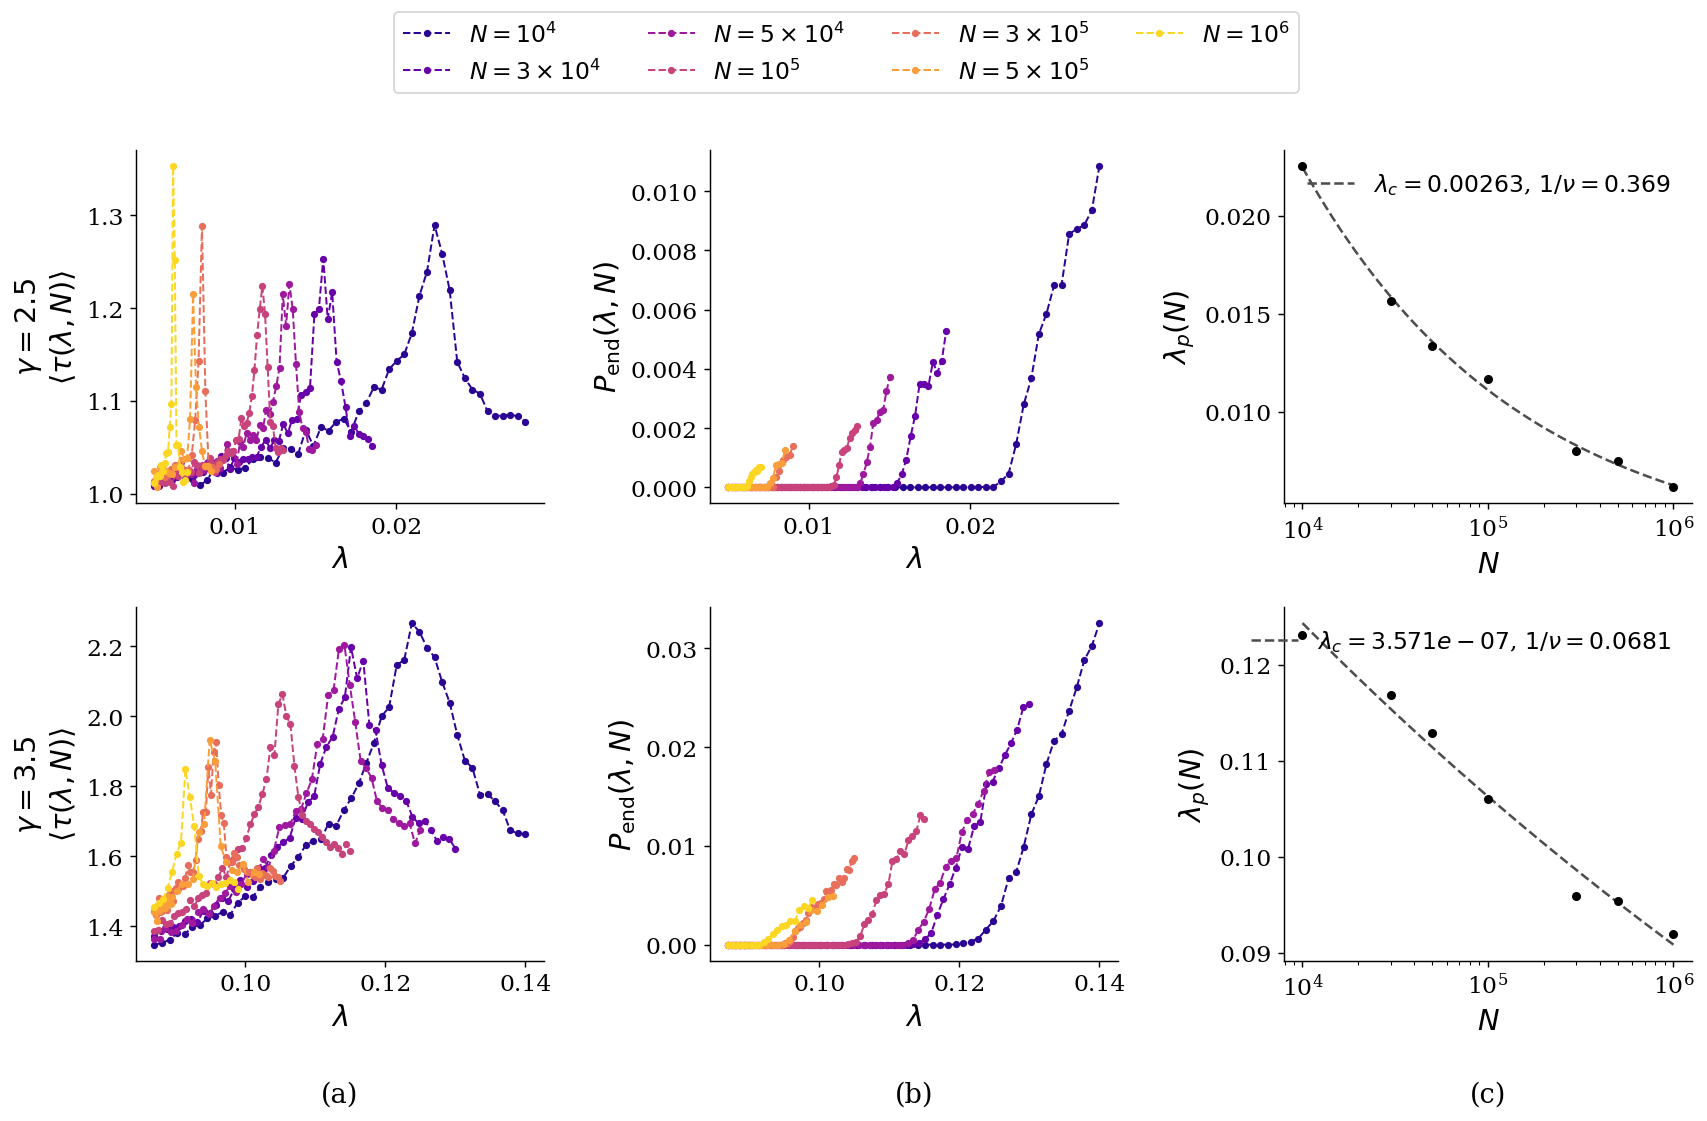

In [13]:
# Figura d'estil "article": graella 2x3 amb llegenda compartida a dalt,
# paleta plasma -- mateixa estructura que la de collapse (report_collapse_
# abc_combined): files = gamma (2.5 a dalt, 3.5 a baix), columnes = (a)
# <tau(lambda,N)>, (b) P_end(lambda,N), (c) ajust del desplacament del pic
# lambda_p(N). Lletra grossa i sense graella (REPORT_RC, seccio 2).

gammas_ok_c = sorted(fit_results.keys())
if gammas_ok_c:
    with plt.rc_context(REPORT_RC):
        fig, axes = plt.subplots(len(gammas_ok_c), 3, figsize=(13.5, 4.2 * len(gammas_ok_c)))
        if len(gammas_ok_c) == 1:
            axes = axes.reshape(1, 3)
        handles, labels = [], []

        for row, gamma in enumerate(gammas_ok_c):
            sub_raw = raw_scans[raw_scans["gamma"] == gamma]
            ax_tau, ax_pend, ax_fit = axes[row][0], axes[row][1], axes[row][2]

            for N in sorted(sub_raw["N"].unique()):
                color = N_COLOR_PLASMA.get(int(N), "black")
                g_pk = pool_same_tag(sub_raw[sub_raw["N"] == N], PEAK_TAGS)
                if g_pk.empty:
                    continue
                g_pk = g_pk.sort_values("lambda")
                line, = ax_tau.plot(g_pk["lambda"], g_pk["tau_mean"], "o--", ms=3, lw=1.1, color=color)
                ax_pend.plot(g_pk["lambda"], g_pk["P_end"], "o--", ms=3, lw=1.1, color=color)
                if row == 0:
                    handles.append(line)
                    labels.append(_n_label(N))

            ax_tau.set_xlabel(r"$\lambda$")
            ax_tau.set_ylabel(rf"$\gamma={gamma}$" + "\n" + r"$\langle\tau(\lambda,N)\rangle$")
            clean_ax(ax_tau)

            ax_pend.set_xlabel(r"$\lambda$"); ax_pend.set_ylabel(r"$P_{\rm end}(\lambda,N)$")
            clean_ax(ax_pend)

            peaks, popt = fit_results[gamma]
            lambda_c, a, inv_nu = popt
            N_plot = np.logspace(np.log10(peaks["N"].min()), np.log10(peaks["N"].max()), 200)
            ax_fit.scatter(peaks["N"], peaks["lambda_p"], color="black", zorder=3)
            ax_fit.plot(N_plot, lambda_peak_model(N_plot, *popt), color="0.3", lw=1.4, ls="--",
                        label=rf"$\lambda_c={lambda_c:.4g}$, $1/\nu={inv_nu:.3g}$")
            ax_fit.set_xscale("log")
            ax_fit.set_xlabel(r"$N$"); ax_fit.set_ylabel(r"$\lambda_p(N)$")
            clean_ax(ax_fit)
            ax_fit.legend()

            if row == len(gammas_ok_c) - 1:
                for ax, letter in zip((ax_tau, ax_pend, ax_fit), "abc"):
                    ax.text(0.5, -0.34, f"({letter})", transform=ax.transAxes, ha="center", va="top", fontsize=15)

        fig.legend(handles, labels, loc="upper center", ncol=4,
                   bbox_to_anchor=(0.5, 1.0 + 0.10 / len(gammas_ok_c)), frameon=True)
        plt.tight_layout(rect=[0, 0, 1, 0.94])
        plt.savefig(FIG_DIR / "report_2x3_raw_and_fit.png", bbox_inches="tight")
        plt.savefig(FIG_DIR / "report_2x3_raw_and_fit.pdf", bbox_inches="tight")
        plt.show()

## 9. Exponent gamma_n/nu a partir de l'alçada del pic



,gamma,gamma1_over_nu,intercept1,gamma2_over_nu,intercept2
0,2.5,-0.031867,0.751366,0.591070,-2.384739
1,3.5,-0.001853,0.842956,0.423999,0.047963


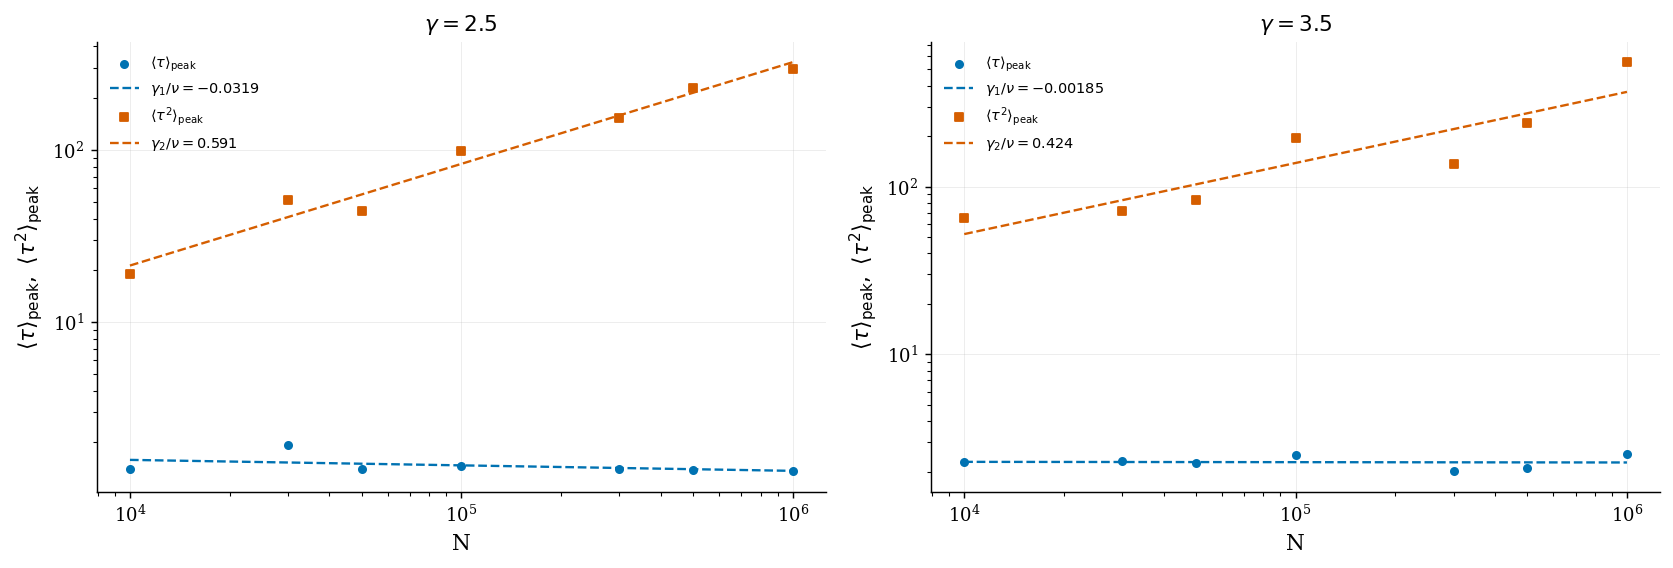

Com esperavem: gamma1/nu surt proper a 0 per almenys un gamma -- confirma que cal fer servir tau^2 per aquest exponent (delta~1).


In [14]:
# gamma1/nu (a partir de tau) i gamma2/nu (a partir de tau^2)

def fit_power_law_N(N, y):
    N = np.asarray(N, dtype=float); y = np.asarray(y, dtype=float)
    mask = (N > 0) & (y > 0) & np.isfinite(y)
    if mask.sum() < 2:
        return np.nan, np.nan
    xlog = np.log(N[mask]); ylog = np.log(y[mask])
    slope, intercept = np.polyfit(xlog, ylog, 1)
    return slope, intercept

gamma_rows = []
per_gamma_peaks = {}  # gamma -> (peaks_tau, slope1, intercept1, peaks_tau2, slope2, intercept2)

for gamma in sorted(results["gamma"].unique()) if not results.empty else []:
    peaks_tau = extract_peaks(results, gamma, "tau_mean", window=3).dropna(subset=["lambda_p", "peak"])
    peaks_tau2 = extract_peaks(results, gamma, "tau2_mean", window=7).dropna(subset=["lambda_p", "peak"])

    slope1, intercept1 = fit_power_law_N(peaks_tau["N"], peaks_tau["peak"])
    slope2, intercept2 = fit_power_law_N(peaks_tau2["N"], peaks_tau2["peak"])

    gamma_rows.append({
        "gamma": gamma, "gamma1_over_nu": slope1, "intercept1": intercept1,
        "gamma2_over_nu": slope2, "intercept2": intercept2,
    })
    per_gamma_peaks[gamma] = (peaks_tau, slope1, intercept1, peaks_tau2, slope2, intercept2)

gamma_df = pd.DataFrame(gamma_rows)
display(gamma_df)

# Un sol panell per gamma amb tau i tau^2 junts (abans sortien en dos eixos
# separats dins la mateixa figura, un per gamma); ara son nomes dos panells,
# un per gamma, i cada un mostra els dos moments alhora per comparar-ne
# directament els pendents (gamma_1/nu i gamma_2/nu).
COLOR_TAU = "#0072B2"   # blau
COLOR_TAU2 = "#D55E00"  # vermello

gammas_ok = sorted(per_gamma_peaks.keys())
if gammas_ok:
    fig, axes = plt.subplots(1, len(gammas_ok), figsize=(6.5 * len(gammas_ok), 4.5), squeeze=False)
    axes = axes[0]
    for ax, gamma in zip(axes, gammas_ok):
        peaks_tau, slope1, intercept1, peaks_tau2, slope2, intercept2 = per_gamma_peaks[gamma]

        ax.scatter(peaks_tau["N"], peaks_tau["peak"], color=COLOR_TAU, zorder=3,
                   label=r"$\langle\tau\rangle_{\rm peak}$")
        if np.isfinite(slope1):
            N_plot = np.logspace(np.log10(peaks_tau["N"].min()), np.log10(peaks_tau["N"].max()), 200)
            ax.plot(N_plot, np.exp(intercept1) * N_plot ** slope1, color=COLOR_TAU, lw=1.3, ls="--",
                    label=rf"$\gamma_1/\nu={slope1:.3g}$")

        ax.scatter(peaks_tau2["N"], peaks_tau2["peak"], color=COLOR_TAU2, marker="s", zorder=3,
                   label=r"$\langle\tau^2\rangle_{\rm peak}$")
        if np.isfinite(slope2):
            N_plot2 = np.logspace(np.log10(peaks_tau2["N"].min()), np.log10(peaks_tau2["N"].max()), 200)
            ax.plot(N_plot2, np.exp(intercept2) * N_plot2 ** slope2, color=COLOR_TAU2, lw=1.3, ls="--",
                    label=rf"$\gamma_2/\nu={slope2:.3g}$")

        ax.set_xscale("log"); ax.set_yscale("log")
        ax.set_xlabel("N"); ax.set_ylabel(r"$\langle\tau\rangle_{\rm peak},\ \langle\tau^2\rangle_{\rm peak}$")
        ax.set_title(rf"$\gamma={gamma}$")
        clean_ax(ax)
        ax.legend(fontsize=8)

    plt.tight_layout()
    plt.savefig(FIG_DIR / "peak_height_scaling_combined.png")
    plt.show()

if not gamma_df.empty:
    flat_g1 = (gamma_df["gamma1_over_nu"].abs() < 0.1).any()
    if flat_g1:
        print("Com esperavem: gamma1/nu surt proper a 0 per almenys un gamma -- "
              "confirma que cal fer servir tau^2 per aquest exponent (delta~1).")

## 10. beta/nu a partir de P_end 


Avaluar l'ordre al pseudo-punt-crític λp(N) de cada mida, en comptes del λc extrapolat. l'argument d'escalat és el mateix, ja que λp(N)-λc ~ N^(-1/nu) es fa
petit, i té l'avantatge que sempre cau dins la finestra que realment hem escanejat.


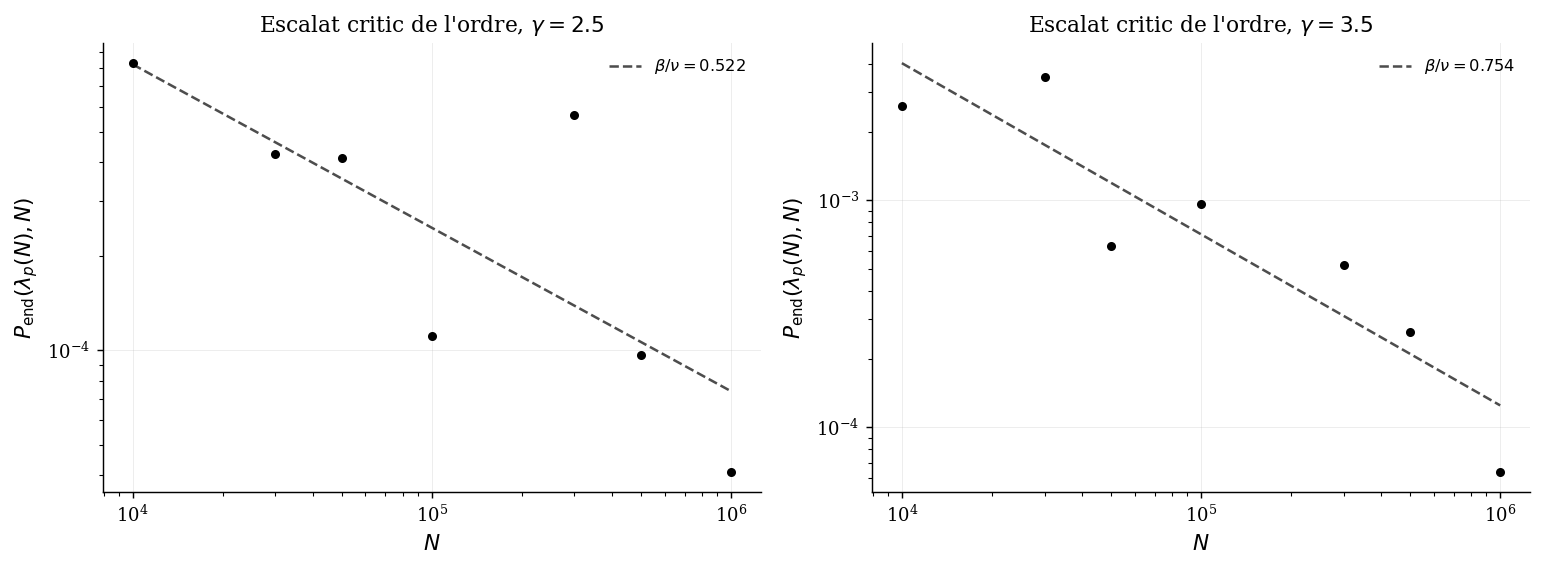

,gamma,N,lambda_p,P_end_at_peak
0,2.5,10000,0.022540,0.000828
1,2.5,30000,0.015641,0.000425
2,2.5,50000,0.013356,0.000414
3,2.5,100000,0.011667,0.000111
4,2.5,300000,0.008023,0.000567
5,2.5,500000,0.007487,0.000096
6,2.5,1000000,0.006158,0.000041
7,3.5,10000,0.123078,0.002619
8,3.5,30000,0.116904,0.003493
9,3.5,50000,0.112879,0.000632


,gamma,beta_over_nu,intercept,n_points
0,2.5,0.522307,-2.294189,7
1,3.5,0.754113,1.431331,7


In [15]:
# P_end(lambda_p(N), N) i beta/nu -- avaluat al pic propi de cada N, no al lambda_c extrapolat

def interpolate_at(g, y_col, x_target):
    g = g.sort_values("lambda")
    x = g["lambda"].values.astype(float)
    y = g[y_col].values.astype(float)
    mask = np.isfinite(x) & np.isfinite(y)
    x, y = x[mask], y[mask]
    if len(x) < 2 or x_target < x.min() or x_target > x.max():
        return np.nan
    f = interp1d(x, y, kind="linear", bounds_error=False, fill_value=np.nan)
    return float(f(x_target))

beta_rows = []
pendcrit_rows = []
per_gamma_beta = {}  # gamma -> (valid, slope, intercept, beta_over_nu) -- per fer despres un sol plot

for gamma in sorted(results["gamma"].unique()) if not results.empty else []:
    peaks_tau = extract_peaks(results, gamma, "tau_mean", window=3).dropna(subset=["lambda_p", "peak"])
    sub = results[results["gamma"] == gamma]

    rows = []
    for _, prow in peaks_tau.iterrows():
        Nval, lam_p = prow["N"], prow["lambda_p"]
        g = sub[sub["N"] == Nval]
        pc = interpolate_at(g, "P_end", lam_p)
        rows.append({"gamma": gamma, "N": int(Nval), "lambda_p": lam_p, "P_end_at_peak": pc})

    pc_df = pd.DataFrame(rows)
    pendcrit_rows.append(pc_df)

    valid = pc_df.dropna()
    valid = valid[(valid["P_end_at_peak"] > 0) & (valid["P_end_at_peak"] < 1)]

    if len(valid) < 2:
        print(f"gamma={gamma}: nomes {len(valid)} punts valids de P_end(lambda_p(N)) -- "
              f"no es pot ajustar beta/nu. Prova d'afegir mes runs a prop del pic (seccio 5).")
        continue

    slope, intercept = fit_power_law_N(valid["N"], valid["P_end_at_peak"])
    beta_over_nu = -slope
    beta_rows.append({"gamma": gamma, "beta_over_nu": beta_over_nu, "intercept": intercept,
                       "n_points": len(valid)})
    per_gamma_beta[gamma] = (valid, slope, intercept, beta_over_nu)

# Un sol plot amb els dos gammes costat a costat (abans en sortien dos de separats)
gammas_ok = sorted(per_gamma_beta.keys())
if gammas_ok:
    fig, axes = plt.subplots(1, len(gammas_ok), figsize=(6 * len(gammas_ok), 4.5), squeeze=False)
    axes = axes[0]
    for ax, gamma in zip(axes, gammas_ok):
        valid, slope, intercept, beta_over_nu = per_gamma_beta[gamma]
        N_plot = np.logspace(np.log10(valid["N"].min()), np.log10(valid["N"].max()), 200)
        ax.scatter(valid["N"], valid["P_end_at_peak"], color=ACCENT, zorder=3)
        ax.plot(N_plot, np.exp(intercept) * N_plot ** slope, color="0.3", lw=1.4, ls="--",
                label=rf"$\beta/\nu={beta_over_nu:.3g}$")
        ax.set_xscale("log"); ax.set_yscale("log")
        ax.set_xlabel(r"$N$"); ax.set_ylabel(r"$P_{\rm end}(\lambda_p(N),N)$")
        ax.set_title(rf"Escalat critic de l'ordre, $\gamma={gamma}$")
        clean_ax(ax)
        ax.legend()
    plt.tight_layout()
    plt.savefig(FIG_DIR / "pend_peak_combined.png")
    plt.show()

pendcrit_df = pd.concat(pendcrit_rows, ignore_index=True) if pendcrit_rows else pd.DataFrame()
beta_df = pd.DataFrame(beta_rows)

display(pendcrit_df)
display(beta_df)

if beta_df.empty:
    print("\n[AVIS] beta_df ha quedat buit -- probablement falten punts de P_end diferents de 0/1 "
          "a prop del pic per alguna N. Amb les dades actuals aixo pot passar per gamma=2.5; "
          "activa la seccio 5 (mes repeticions) per arreglar-ho abans de fer servir el collapse.")

# plot de taus i el colapse


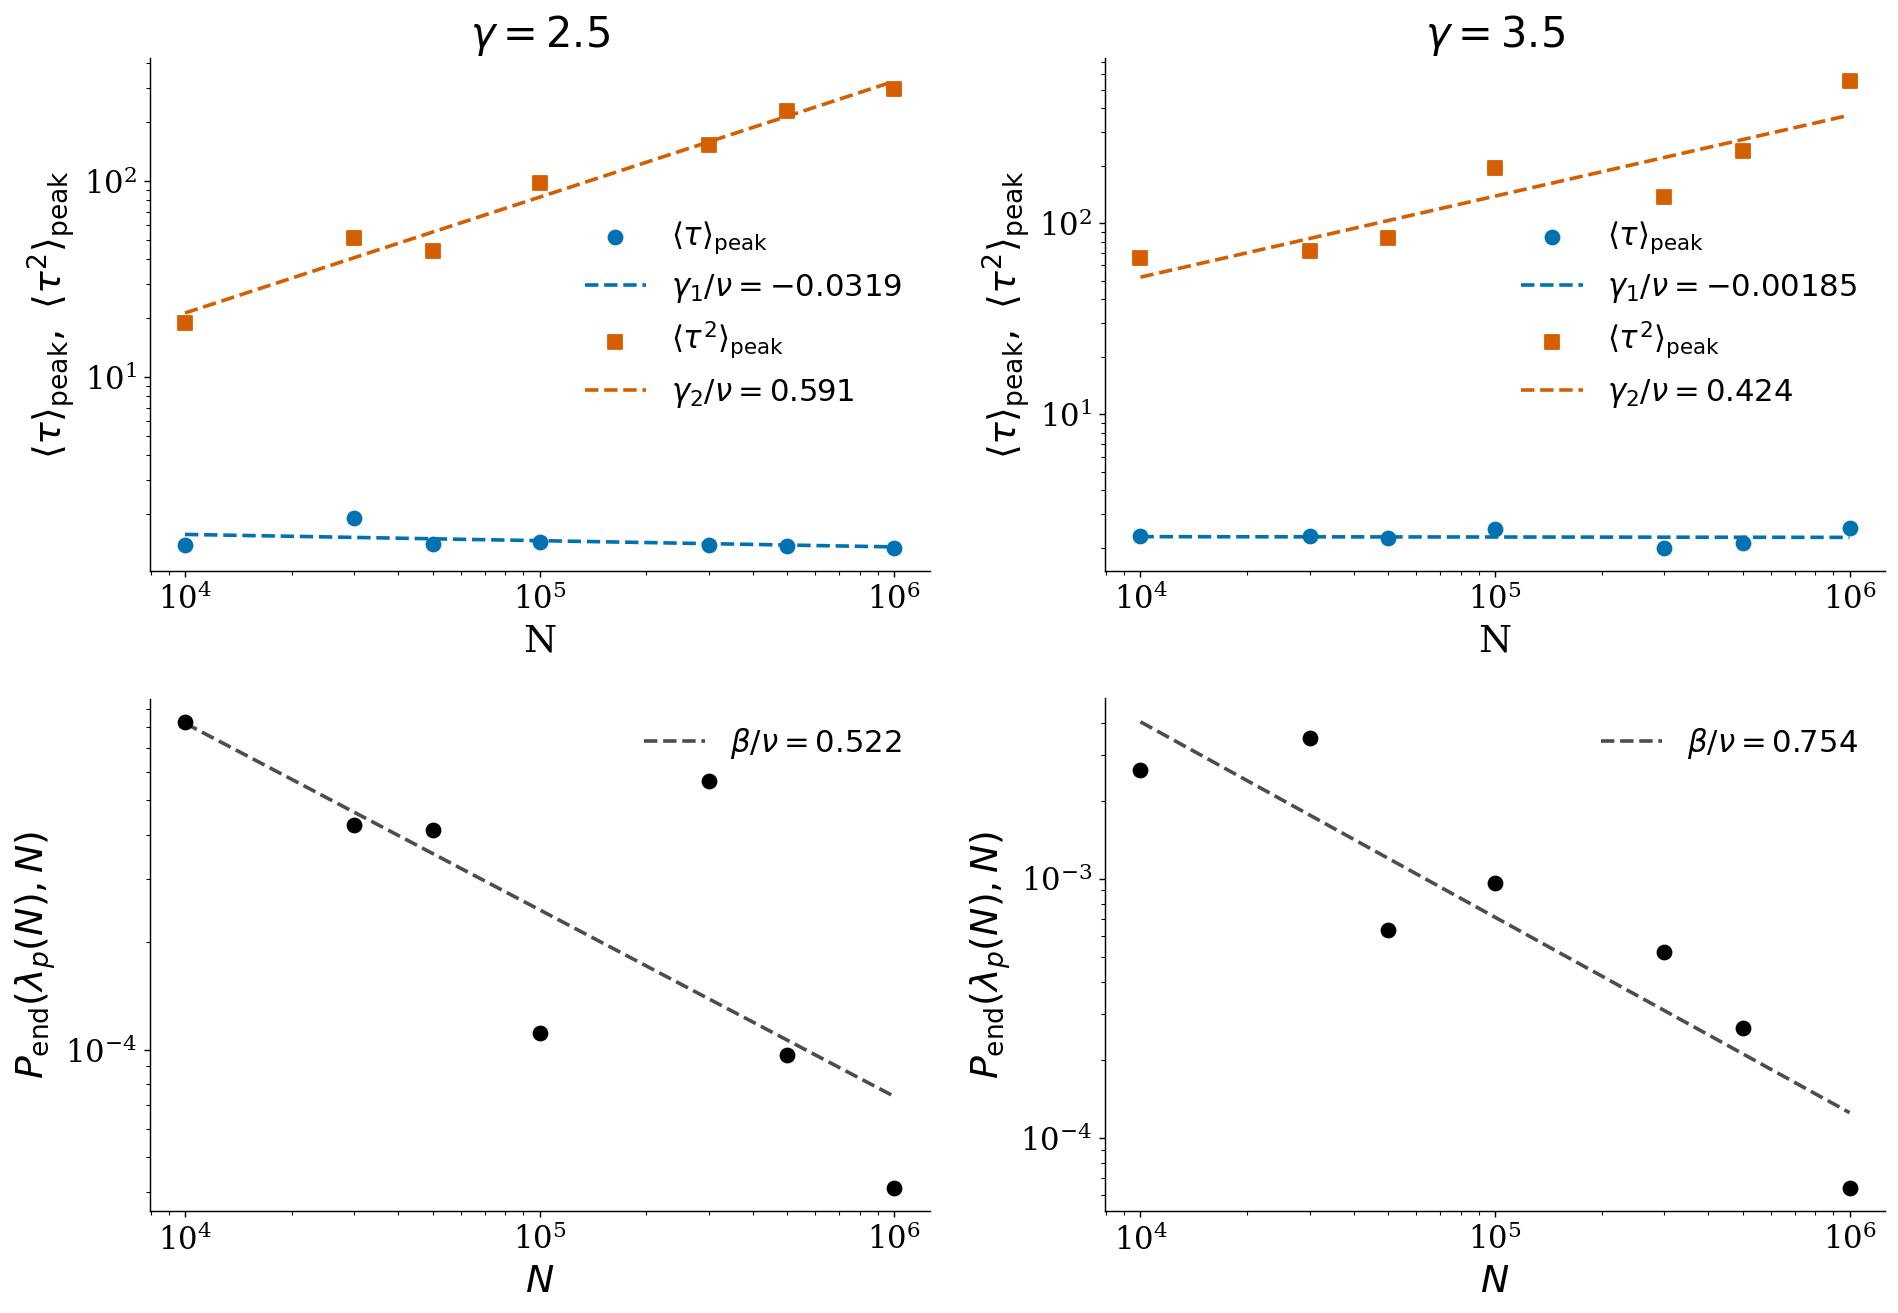

In [17]:
# Figura nativa per a l'informe (punts 4 i 5 de l'enunciat): graella 2x2
# vectorial (PDF), fila de dalt = escalat de l'alcada del pic (gamma_n/nu),
# fila de baix = escalat de P_end al pic (beta/nu). Igual que report_point3,
# generada directament com una sola figura de matplotlib en comptes
# d'ajuntar dues imatges PNG amb PIL.
# Aqui faig servir un estil encara mes gran que REPORT_RC (nomes 4 panells,
# hi ha molt mes espai per lletra que a les graelles de 6) perque seguia
# costant de llegir.

POINT45_RC = dict(REPORT_RC)
POINT45_RC.update({
    "font.size": 20,
    "axes.titlesize": 23,
    "axes.labelsize": 21,
    "xtick.labelsize": 17,
    "ytick.labelsize": 17,
    "legend.fontsize": 17,
})

gammas_ok_p45 = sorted(set(per_gamma_peaks.keys()) & set(per_gamma_beta.keys()))
if gammas_ok_p45:
    with plt.rc_context(POINT45_RC):
        fig, axes = plt.subplots(2, len(gammas_ok_p45), figsize=(7.5 * len(gammas_ok_p45), 10.5), squeeze=False)

        for col, gamma in enumerate(gammas_ok_p45):
            peaks_tau, slope1, intercept1, peaks_tau2, slope2, intercept2 = per_gamma_peaks[gamma]
            ax_h = axes[0][col]
            ax_h.scatter(peaks_tau["N"], peaks_tau["peak"], color=COLOR_TAU, zorder=3, s=60,
                         label=r"$\langle\tau\rangle_{\rm peak}$")
            if np.isfinite(slope1):
                N_plot = np.logspace(np.log10(peaks_tau["N"].min()), np.log10(peaks_tau["N"].max()), 200)
                ax_h.plot(N_plot, np.exp(intercept1) * N_plot ** slope1, color=COLOR_TAU, lw=2.0, ls="--",
                          label=rf"$\gamma_1/\nu={slope1:.3g}$")
            ax_h.scatter(peaks_tau2["N"], peaks_tau2["peak"], color=COLOR_TAU2, marker="s", zorder=3, s=60,
                         label=r"$\langle\tau^2\rangle_{\rm peak}$")
            if np.isfinite(slope2):
                N_plot2 = np.logspace(np.log10(peaks_tau2["N"].min()), np.log10(peaks_tau2["N"].max()), 200)
                ax_h.plot(N_plot2, np.exp(intercept2) * N_plot2 ** slope2, color=COLOR_TAU2, lw=2.0, ls="--",
                          label=rf"$\gamma_2/\nu={slope2:.3g}$")
            ax_h.set_xscale("log"); ax_h.set_yscale("log")
            ax_h.set_xlabel("N"); ax_h.set_ylabel(r"$\langle\tau\rangle_{\rm peak},\ \langle\tau^2\rangle_{\rm peak}$")
            ax_h.set_title(rf"$\gamma={gamma}$")
            clean_ax(ax_h)
            ax_h.legend()

            valid, slope, intercept, beta_over_nu = per_gamma_beta[gamma]
            N_plot3 = np.logspace(np.log10(valid["N"].min()), np.log10(valid["N"].max()), 200)
            ax_b = axes[1][col]
            ax_b.scatter(valid["N"], valid["P_end_at_peak"], color=ACCENT, zorder=3, s=60)
            ax_b.plot(N_plot3, np.exp(intercept) * N_plot3 ** slope, color="0.3", lw=2.0, ls="--",
                      label=rf"$\beta/\nu={beta_over_nu:.3g}$")
            ax_b.set_xscale("log"); ax_b.set_yscale("log")
            ax_b.set_xlabel(r"$N$"); ax_b.set_ylabel(r"$P_{\rm end}(\lambda_p(N),N)$")
            clean_ax(ax_b)
            ax_b.legend()

        plt.tight_layout()
        plt.savefig(FIG_DIR / "report_point45.png")
        plt.savefig(FIG_DIR / "report_point45.pdf")
        plt.show()

## 11. Collapse plots



N^(beta/nu) P_end  vs  (lambda-lambda_c)·N^(1/nu)

N^(-gamma2/nu) tau^2  vs  (lambda-lambda_c)·N^(1/nu)


També hi poso el col·lapse amb tau (1r moment) a sota, per comparar-los 



,gamma,lambda_c,lambda_c_err,inv_nu,inv_nu_err,gamma1_over_nu,gamma2_over_nu,beta_over_nu,gamma1_over_nu_collapse,gamma1_collapse_reliable,gamma2_over_nu_collapse,gamma2_collapse_reliable,beta_over_nu_collapse,beta_collapse_reliable
0,2.5,2.630226e-03,0.001034,0.368639,0.040110,-0.031867,0.591070,0.522307,0.000003,False,0.341332,True,0.000003,False
1,3.5,3.571270e-07,0.154306,0.068132,0.098823,-0.001853,0.423999,0.754113,0.000003,False,0.072841,False,0.000003,False


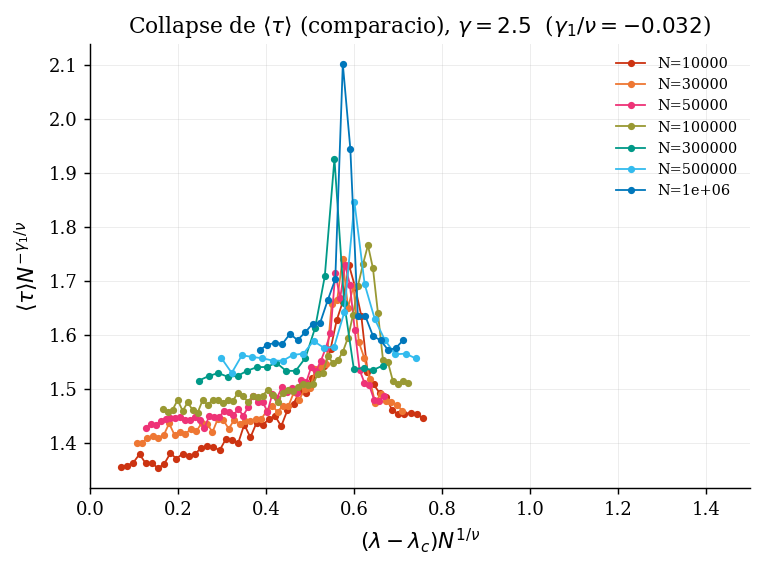

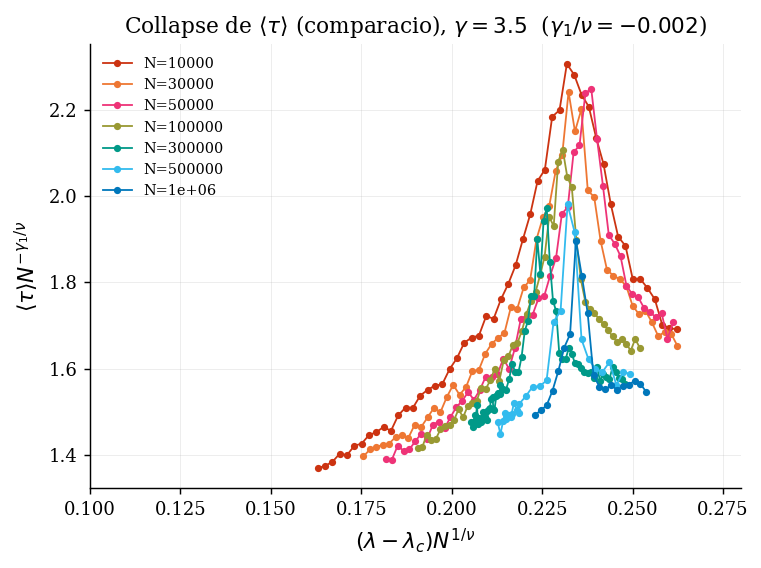

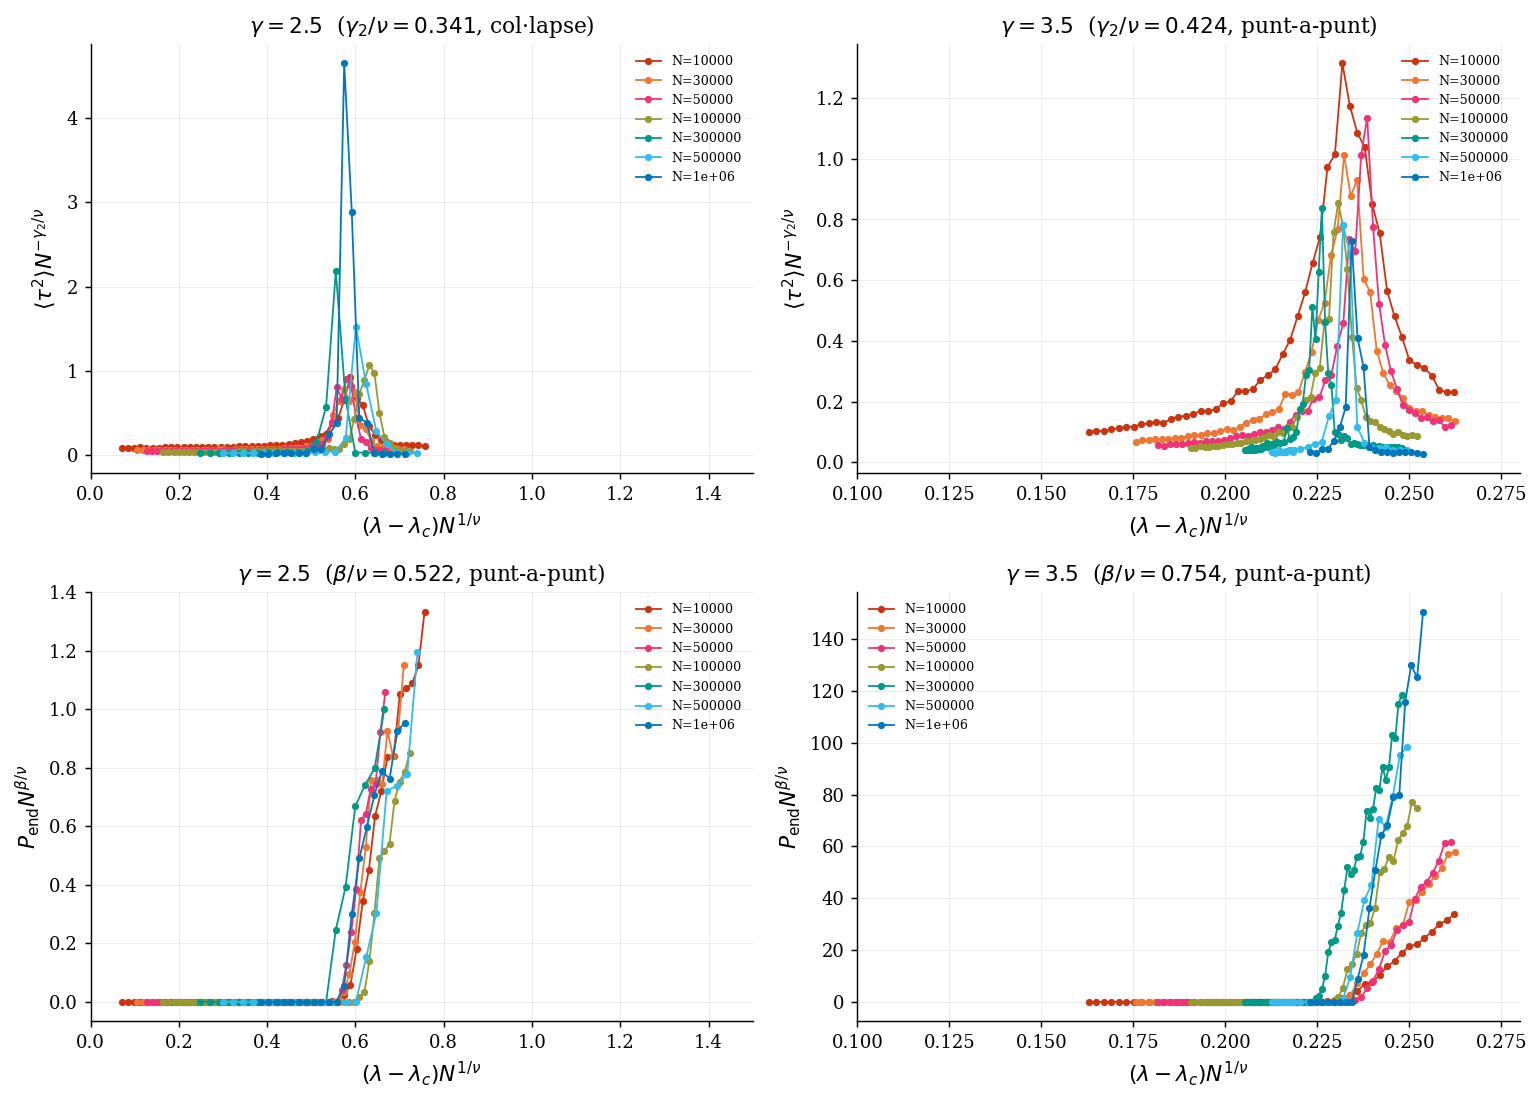

In [18]:
# Muntem exp_df (tots els exponents junts, punt-a-punt i de col·lapse) i fem els collapse plots

def build_exponent_summary(fit_df, gamma_df, beta_df, collapse_df):
    rows = []
    if fit_df.empty:
        print("[AVIS] fit_df (lambda_c, 1/nu) buit -- no es pot muntar cap collapse.")
        return pd.DataFrame()

    for _, frow in fit_df.iterrows():
        gamma = frow["gamma"]
        g1 = gamma_df[gamma_df["gamma"] == gamma] if not gamma_df.empty else pd.DataFrame()
        b = beta_df[beta_df["gamma"] == gamma] if not beta_df.empty else pd.DataFrame()
        c = collapse_df[collapse_df["gamma"] == gamma] if not collapse_df.empty else pd.DataFrame()

        if g1.empty:
            print(f"gamma={gamma}: no tinc gamma1/gamma2 sobre nu -- salto aquest gamma pel collapse.")
            continue
        if b.empty:
            print(f"gamma={gamma}: no tinc beta/nu literal (mira l'avis de la seccio 10) -- "
                  f"encara puc fer servir el de col·lapse si es fiable.")

        row = {
            "gamma": gamma,
            "lambda_c": frow["lambda_c"],
            "lambda_c_err": frow["lambda_c_err"],
            "inv_nu": frow["inv_nu"],
            "inv_nu_err": frow["inv_nu_err"],
            "gamma1_over_nu": float(g1["gamma1_over_nu"].iloc[0]),
            "gamma2_over_nu": float(g1["gamma2_over_nu"].iloc[0]),
            "beta_over_nu": float(b["beta_over_nu"].iloc[0]) if not b.empty else np.nan,
            "gamma1_over_nu_collapse": np.nan, "gamma1_collapse_reliable": False,
            "gamma2_over_nu_collapse": np.nan, "gamma2_collapse_reliable": False,
            "beta_over_nu_collapse": np.nan, "beta_collapse_reliable": False,
        }
        if not c.empty:
            crow = c.iloc[0]
            row["gamma1_over_nu_collapse"] = float(crow["gamma1_over_nu_collapse"])
            row["gamma1_collapse_reliable"] = bool(crow["gamma1_collapse_reliable"])
            row["gamma2_over_nu_collapse"] = float(crow["gamma2_over_nu_collapse"])
            row["gamma2_collapse_reliable"] = bool(crow["gamma2_collapse_reliable"])
            row["beta_over_nu_collapse"] = float(crow["beta_over_nu_collapse"])
            row["beta_collapse_reliable"] = bool(crow["beta_collapse_reliable"])
        rows.append(row)
    return pd.DataFrame(rows)

exp_df = build_exponent_summary(fit_df, gamma_df, beta_df, collapse_df)
display(exp_df)

# Zoom demanat per centrar-nos en la zona on hi ha col·lapse de veritat, en comptes
# de deixar que les cues llunyanes (que mai col·lapsen del tot, sobretot per pocs
# punts a les N grans) dominin l'escala del plot.
COLLAPSE_XLIM = {
    2.5: (0.0, 1.5),
    3.5: (0.1, 0.28),
}

def _prep_scaled(raw, gamma, lambda_c, inv_nu, gamma2_over_nu, beta_over_nu):
    """Nomes adaptive_boost: mateixa resolucio fina a totes les N. Fer-ho amb
    `results` (totes les fonts juntes, resolucions molt diferents) es el que
    feia que les linies sortissin en dents de serra -- exactament el mateix
    problema que ja vam solucionar pel plot de tau/tau2/pend (seccio 7)."""
    sub = raw[(raw["gamma"] == gamma) & (raw["source_tag"] == "adaptive_boost")].copy()
    sub = pool_scan_rows(sub)
    sub["x_scaled"] = (sub["lambda"] - lambda_c) * (sub["N"] ** inv_nu)
    sub["tau2_scaled"] = sub["tau2_mean"] * (sub["N"] ** (-gamma2_over_nu))
    if np.isfinite(beta_over_nu):
        sub["pend_scaled"] = sub["P_end"] * (sub["N"] ** beta_over_nu)
    return sub

def plot_collapses(raw, exp_df):
    exp_by_gamma = {row["gamma"]: row for _, row in exp_df.iterrows()}
    gammas_ok = sorted(exp_by_gamma.keys())
    if not gammas_ok:
        print("exp_df buit -- no hi ha res per fer collapse.")
        return

    # --- tau collapse (nomes de comparacio -- s'espera pitjor, gamma1/nu no fiable) ---
    # Es queda un plot per gamma, ja que aixo nomes ho fem servir per il·lustrar
    # la patologia delta~1 (seccio de discussio), no com a resultat principal.
    for gamma in gammas_ok:
        erow = exp_by_gamma[gamma]
        lambda_c, inv_nu = erow["lambda_c"], erow["inv_nu"]
        gamma1_over_nu = erow["gamma1_over_nu_collapse"] if erow["gamma1_collapse_reliable"] else erow["gamma1_over_nu"]
        gamma2_over_nu = erow["gamma2_over_nu_collapse"] if erow["gamma2_collapse_reliable"] else erow["gamma2_over_nu"]
        beta_over_nu = erow["beta_over_nu_collapse"] if erow["beta_collapse_reliable"] else erow["beta_over_nu"]
        sub = _prep_scaled(raw, gamma, lambda_c, inv_nu, gamma2_over_nu, beta_over_nu)
        sub["tau_scaled"] = sub["tau_mean"] * (sub["N"] ** (-gamma1_over_nu))
        xlim = COLLAPSE_XLIM.get(gamma)

        plt.figure(figsize=(6, 4.5))
        for N, g in sub.groupby("N"):
            g = g.sort_values("x_scaled")
            plt.plot(g["x_scaled"], g["tau_scaled"], marker="o", ms=3, lw=1,
                     color=N_COLOR.get(int(N), ACCENT), label=f"N={N:g}")
        plt.xlabel(r"$(\lambda-\lambda_c)N^{1/\nu}$")
        plt.ylabel(r"$\langle\tau\rangle N^{-\gamma_1/\nu}$")
        plt.title(rf"Collapse de $\langle\tau\rangle$ (comparacio), $\gamma={gamma}$  "
                  rf"($\gamma_1/\nu={gamma1_over_nu:.3f}$)")
        if xlim is not None:
            plt.xlim(*xlim)
        clean_ax()
        plt.legend(fontsize=8)
        plt.tight_layout()
        plt.savefig(FIG_DIR / f"collapse_tau_gamma{gamma}.png")
        plt.show()

    # --- graella 2x2: files = tau^2, P_end -- columnes = gamma -- son els dos
    # collapses que fem servir de veritat, i abans sortien en 4 figures soltes
    # (una per gamma i quantitat). En una sola graella es compara de cop com
    # escala cada moment als dos gammes. ---
    fig, axes = plt.subplots(2, len(gammas_ok), figsize=(6 * len(gammas_ok), 8.6), squeeze=False)

    for col, gamma in enumerate(gammas_ok):
        erow = exp_by_gamma[gamma]
        lambda_c, inv_nu = erow["lambda_c"], erow["inv_nu"]
        gamma2_over_nu = erow["gamma2_over_nu_collapse"] if erow["gamma2_collapse_reliable"] else erow["gamma2_over_nu"]
        beta_over_nu = erow["beta_over_nu_collapse"] if erow["beta_collapse_reliable"] else erow["beta_over_nu"]
        xlim = COLLAPSE_XLIM.get(gamma)
        sub = _prep_scaled(raw, gamma, lambda_c, inv_nu, gamma2_over_nu, beta_over_nu)

        ax_tau2 = axes[0][col]
        for N, g in sub.groupby("N"):
            g = g.sort_values("x_scaled")
            ax_tau2.plot(g["x_scaled"], g["tau2_scaled"], marker="o", ms=3, lw=1,
                         color=N_COLOR.get(int(N), ACCENT), label=f"N={N:g}")
        tag2 = "col·lapse" if erow["gamma2_collapse_reliable"] else "punt-a-punt"
        ax_tau2.set_xlabel(r"$(\lambda-\lambda_c)N^{1/\nu}$")
        ax_tau2.set_ylabel(r"$\langle\tau^2\rangle N^{-\gamma_2/\nu}$")
        ax_tau2.set_title(rf"$\gamma={gamma}$  ($\gamma_2/\nu={gamma2_over_nu:.3f}$, {tag2})")
        if xlim is not None:
            ax_tau2.set_xlim(*xlim)
        clean_ax(ax_tau2)
        ax_tau2.legend(fontsize=7)

        ax_pend = axes[1][col]
        if np.isfinite(beta_over_nu):
            for N, g in sub.groupby("N"):
                g = g.sort_values("x_scaled")
                ax_pend.plot(g["x_scaled"], g["pend_scaled"], marker="o", ms=3, lw=1,
                             color=N_COLOR.get(int(N), ACCENT), label=f"N={N:g}")
            tagb = "col·lapse" if erow["beta_collapse_reliable"] else "punt-a-punt"
            ax_pend.set_title(rf"$\gamma={gamma}$  ($\beta/\nu={beta_over_nu:.3f}$, {tagb})")
            ax_pend.legend(fontsize=7)
        else:
            ax_pend.text(0.5, 0.5, r"sense $\beta/\nu$", ha="center", va="center", transform=ax_pend.transAxes)
            print(f"gamma={gamma}: sense beta/nu (ni literal ni de col·lapse), no es pot fer el collapse de P_end.")
        ax_pend.set_xlabel(r"$(\lambda-\lambda_c)N^{1/\nu}$")
        ax_pend.set_ylabel(r"$P_{\rm end}N^{\beta/\nu}$")
        if xlim is not None:
            ax_pend.set_xlim(*xlim)
        clean_ax(ax_pend)

    plt.tight_layout()
    plt.savefig(FIG_DIR / "collapse_2x2_combined.png")
    plt.savefig(FIG_DIR / "collapse_2x2_combined.pdf")  # vectorial, per l'informe
    plt.show()

if not exp_df.empty:
    plot_collapses(raw_scans, exp_df)
else:
    print("exp_df buit -- revisa els avisos de les seccions anteriors abans de continuar.")

# I el que va al report

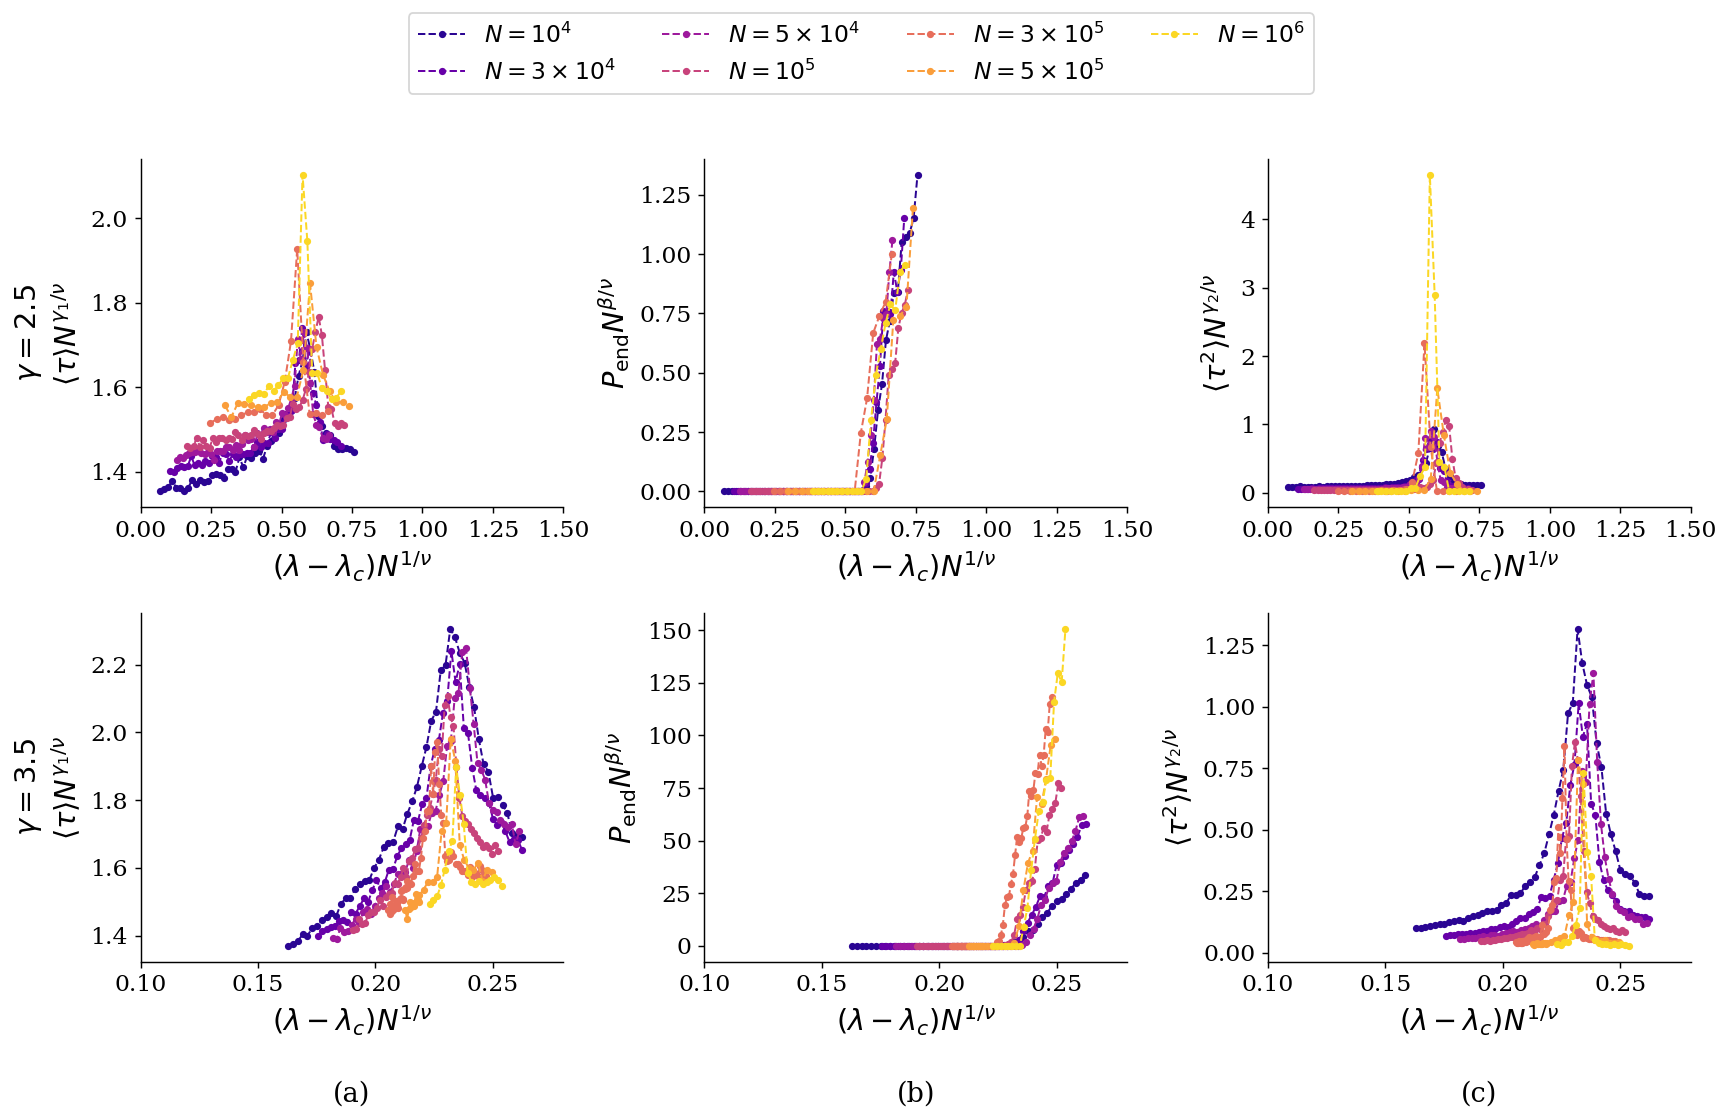

In [19]:
# Figura d'estil "article": collapse en una sola graella, files = gamma
# (2.5 a dalt, 3.5 a baix), columnes = (a) <tau>, (b) P_end, (c) <tau^2>,
# amb llegenda compartida a dalt, paleta plasma. Lletra grossa i sense
# graella (REPORT_RC, seccio 2).

def _prep_scaled_full(raw, gamma, lambda_c, inv_nu, gamma1_over_nu, gamma2_over_nu, beta_over_nu):
    sub = raw[(raw["gamma"] == gamma) & (raw["source_tag"] == "adaptive_boost")].copy()
    sub = pool_scan_rows(sub)
    sub["x_scaled"] = (sub["lambda"] - lambda_c) * (sub["N"] ** inv_nu)
    sub["tau_scaled"] = sub["tau_mean"] * (sub["N"] ** (-gamma1_over_nu))
    sub["tau2_scaled"] = sub["tau2_mean"] * (sub["N"] ** (-gamma2_over_nu))
    has_pend = bool(np.isfinite(beta_over_nu))
    if has_pend:
        sub["pend_scaled"] = sub["P_end"] * (sub["N"] ** beta_over_nu)
    return sub, has_pend

def plot_collapse_abc(raw, exp_df):
    exp_by_gamma = {row["gamma"]: row for _, row in exp_df.iterrows()}
    gammas_ok = sorted(exp_by_gamma.keys())
    if not gammas_ok:
        return

    with plt.rc_context(REPORT_RC):
        fig, axes = plt.subplots(len(gammas_ok), 3, figsize=(13.5, 4.2 * len(gammas_ok)))
        if len(gammas_ok) == 1:
            axes = axes.reshape(1, 3)
        handles, labels = [], []

        for row, gamma in enumerate(gammas_ok):
            erow = exp_by_gamma[gamma]
            lambda_c, inv_nu = erow["lambda_c"], erow["inv_nu"]
            gamma1_over_nu = erow["gamma1_over_nu_collapse"] if erow["gamma1_collapse_reliable"] else erow["gamma1_over_nu"]
            gamma2_over_nu = erow["gamma2_over_nu_collapse"] if erow["gamma2_collapse_reliable"] else erow["gamma2_over_nu"]
            beta_over_nu = erow["beta_over_nu_collapse"] if erow["beta_collapse_reliable"] else erow["beta_over_nu"]
            xlim = COLLAPSE_XLIM.get(gamma)
            sub, has_pend = _prep_scaled_full(raw, gamma, lambda_c, inv_nu, gamma1_over_nu, gamma2_over_nu, beta_over_nu)

            ax_tau, ax_pend, ax_tau2 = axes[row][0], axes[row][1], axes[row][2]
            for N, g in sub.groupby("N"):
                g = g.sort_values("x_scaled")
                color = N_COLOR_PLASMA.get(int(N), "black")
                line, = ax_tau.plot(g["x_scaled"], g["tau_scaled"], "o--", ms=3, lw=1.1, color=color)
                if has_pend:
                    ax_pend.plot(g["x_scaled"], g["pend_scaled"], "o--", ms=3, lw=1.1, color=color)
                ax_tau2.plot(g["x_scaled"], g["tau2_scaled"], "o--", ms=3, lw=1.1, color=color)
                if row == 0:
                    handles.append(line)
                    labels.append(_n_label(N))

            if not has_pend:
                ax_pend.text(0.5, 0.5, r"sense $\beta/\nu$", ha="center", va="center", transform=ax_pend.transAxes)

            ax_tau.set_xlabel(r"$(\lambda-\lambda_c)N^{1/\nu}$")
            ax_tau.set_ylabel(rf"$\gamma={gamma}$" + "\n" + r"$\langle\tau\rangle N^{\gamma_1/\nu}$")
            ax_pend.set_xlabel(r"$(\lambda-\lambda_c)N^{1/\nu}$")
            ax_pend.set_ylabel(r"$P_{\rm end}N^{\beta/\nu}$")
            ax_tau2.set_xlabel(r"$(\lambda-\lambda_c)N^{1/\nu}$")
            ax_tau2.set_ylabel(r"$\langle\tau^2\rangle N^{\gamma_2/\nu}$")

            for ax in (ax_tau, ax_pend, ax_tau2):
                if xlim is not None:
                    ax.set_xlim(*xlim)
                clean_ax(ax)
            if row == len(gammas_ok) - 1:
                for ax, letter in zip((ax_tau, ax_pend, ax_tau2), "abc"):
                    ax.text(0.5, -0.34, f"({letter})", transform=ax.transAxes, ha="center", va="top", fontsize=15)

        fig.legend(handles, labels, loc="upper center", ncol=4,
                   bbox_to_anchor=(0.5, 1.0 + 0.10 / len(gammas_ok)), frameon=True)
        plt.tight_layout(rect=[0, 0, 1, 0.94])
        plt.savefig(FIG_DIR / "report_collapse_abc_combined.png", bbox_inches="tight")
        plt.savefig(FIG_DIR / "report_collapse_abc_combined.pdf", bbox_inches="tight")
        plt.show()

if not exp_df.empty:
    plot_collapse_abc(raw_scans, exp_df)